# XGBRanker — Natives Learning-to-Rank für die Etappenprognose


## Warum XGBRanker?

Die bisherigen Modelle dieses Projekts behandeln die Etappenprognose **pointwise**: Das EBM (Notebook `10-01`) und TabPFN (Notebooks `12-*`) klassifizieren jede Fahrer-Etappen-Kombination isoliert über drei binäre Zielkanäle (Top 5 / Top 10 / Top 20, Frank-&-Hall-Zerlegung), der XGBoost-Regressor (Notebook `11-00`) schätzt eine ordinale Zielgröße pro Fahrer. In allen Fällen entsteht die Rangliste erst **nachgelagert**, indem die pointwise berechneten Scores innerhalb einer Etappe sortiert werden. Das eigentliche sportliche Ziel — *die korrekte Reihenfolge der Fahrer innerhalb einer Etappe* — ist dabei nie Teil des Trainingsziels.

Der `XGBRanker` schließt genau diese Lücke: Er ist die **Learning-to-Rank-Variante (LTR)** von XGBoost und optimiert die Rangfolge innerhalb definierter Gruppen (hier: Etappen) **direkt im Trainingsziel**. Damit beantwortet dieses Notebook die im EBM-Notebook formulierte Limitation:

> *"Da das EBM jede Fahrer-Etappen-Kombination zunächst isoliert bewertet, berücksichtigt es die relative Konkurrenzsituation innerhalb einer Etappe nicht direkt im Trainingsziel. Diese Limitation motiviert den späteren Vergleich mit nativen Learning-to-Rank-Verfahren wie `XGBRanker`."* (Notebook `10-01`)

### Die drei Learning-to-Rank-Paradigmen

Learning-to-Rank-Verfahren werden klassisch in drei Familien eingeteilt (vgl. Liu, 2009):

| Paradigma | Trainingsziel | Beispiel in diesem Projekt |
| :--- | :--- | :--- |
| **Pointwise** | Vorhersage eines Wertes pro Einzelbeobachtung (Klassifikation/Regression); Ranking entsteht durch nachträgliches Sortieren | EBM (`10-01`), TabPFN (`12-*`), XGBoost-Regressor (`11-00`) |
| **Pairwise** | Vorhersage, welches Element eines **Paares** innerhalb einer Gruppe höher stehen sollte; der Fehler wird über Paarvergleiche definiert | **XGBRanker** (dieses Notebook) |
| **Listwise** | Direkte Optimierung einer Metrik über die **gesamte Liste** (z. B. NDCG) | — (LambdaMART enthält listwise-Elemente, s. u.) |

### Von RankNet über LambdaRank zu LambdaMART

Der `XGBRanker` implementiert **LambdaMART** (Burges, 2010). Die Entwicklungslinie ist wichtig, um die Hyperparameter zu verstehen:

1. **RankNet** (Burges et al., 2005): Für jedes Fahrerpaar $(i, j)$ derselben Etappe, bei dem Fahrer $i$ real besser platziert war als Fahrer $j$, soll das Modell Scores $s_i > s_j$ ausgeben. Die Wahrscheinlichkeit dafür wird über eine Sigmoidfunktion der Score-Differenz modelliert und mit der Kreuzentropie bestraft:
$$
P(i \succ j) = \frac{1}{1 + e^{-(s_i - s_j)}}
$$
RankNet behandelt dabei alle Paare gleich — ein Sortierfehler auf Platz 1–2 wiegt genauso schwer wie einer auf Platz 80–81.

2. **LambdaRank** (Burges et al., 2006): Statt die Kreuzentropie direkt abzuleiten, werden die Paar-Gradienten — die sogenannten **Lambdas** ($\lambda_{ij}$) — mit der Änderung der Zielmetrik gewichtet, die ein Vertauschen der beiden Elemente bewirken würde:
$$
\lambda_{ij} = \frac{-\sigma}{1 + e^{\sigma(s_i - s_j)}} \cdot \left| \Delta \text{NDCG}_{ij} \right|
$$
Der Faktor $|\Delta \text{NDCG}_{ij}|$ macht das Verfahren *implizit listwise*: Fehler an der **Spitze der Rangliste** erzeugen große Gradienten, Fehler im Mittelfeld kleine. Für unsere Fragestellung (Top-Platzierungen korrekt prognostizieren) ist genau das erwünscht.

3. **LambdaMART** = LambdaRank-Gradienten + **MART** (Multiple Additive Regression Trees, d. h. Gradient Boosted Trees). Der `XGBRanker` ist damit technisch ein gewöhnliches Gradient-Boosting-Modell — nur die Loss-Gradienten stammen aus Paarvergleichen innerhalb der Gruppen statt aus Einzelbeobachtungen.

### Zentrale Begriffe

- **Query / Gruppe / `qid`**: LTR stammt aus dem Information Retrieval, wo Dokumente je Suchanfrage (*Query*) sortiert werden. In unserem Projekt ist die *Query* eine **Etappe** (`stage_id`) und die *Dokumente* sind die **Fahrer** dieser Etappe. XGBoost erwartet die Gruppenzuordnung entweder als `qid`-Array (numerische Gruppen-ID pro Zeile; die Zeilen müssen dabei **blockweise zusammenhängend und nicht-absteigend sortiert** vorliegen) oder als `group`-Array (Liste der Gruppengrößen). Wir verwenden die `qid`-Variante der sklearn-API.
- **Relevanz-Label**: Die Zielvariable eines Rankers ist kein Rang, sondern eine **Relevanzstufe** (je höher, desto besser). Wir verwenden die im Projekt etablierte vierstufige Kodierung `Top 5 → 3`, `Top 6–10 → 2`, `Top 11–20 → 1`, `Rest → 0` — exakt dieselbe Funktion `rank_to_relevance()`, mit der EBM und TabPFN evaluiert werden. Trainingsziel und Evaluationsziel sind damit identisch definiert.
- **Effective Pairs**: Nur Paare mit **unterschiedlichen** Relevanz-Labels erzeugen einen Lerngradienten (bei zwei Fahrern mit Label 0 gibt es nichts zu ordnen). Mehrstufige Labels (0–3) erzeugen deutlich mehr effective pairs als binäre Labels — ein zentales Argument für die graduierte Kodierung.
- **Margin-Score**: Der Output von `ranker.predict()` ist ein **unkalibrierter, dimensionsloser Score** (die rohe Boosting-Summe, analog zum Logit vor der Sigmoidfunktion). Er ist **keine Wahrscheinlichkeit** und nur **innerhalb einer Etappe** sinnvoll vergleichbar, da das Training ausschließlich Score-*Differenzen* innerhalb von Gruppen optimiert. Absolute Score-Niveaus zwischen Etappen sind nicht kalibriert.
- **NDCG (Normalized Discounted Cumulative Gain)**: Die Standard-Rankingmetrik (Järvelin & Kekäläinen, 2002). Der *Gain* eines Fahrers ist seine Relevanz, der *Discount* fällt logarithmisch mit der Listenposition; die Normalisierung erfolgt gegen die ideale Sortierung:
$$
\text{DCG@}k = \sum_{p=1}^{k} \frac{\text{gain}(rel_p)}{\log_2(p + 1)}, \qquad \text{NDCG@}k = \frac{\text{DCG@}k}{\text{IDCG@}k} \in [0, 1]
$$

### Warum hier kein Frank-&-Hall-Ensemble?

Beim EBM und TabPFN werden drei binäre Klassifikatoren trainiert und deren **Wahrscheinlichkeiten** zu einem Score $P(\text{Top20}) + P(\text{Top10}) + P(\text{Top5}) \in [0, 3]$ summiert. Diese Konstruktion ist auf den XGBRanker **nicht übertragbar** — und auch nicht nötig:

1. Ein Ranker liefert **unkalibrierte Margin-Scores** statt Wahrscheinlichkeiten. Drei separat trainierte Ranker hätten drei beliebig skalierte, nicht vergleichbare Score-Achsen; ihre Summe wäre methodisch nicht interpretierbar (anders als die Summe dreier Wahrscheinlichkeiten auf der gemeinsamen Skala $[0,1]$).
2. Die Frank-&-Hall-Zerlegung existiert, **weil** binäre Klassifikatoren keine ordinale Struktur kennen. Der Ranker benötigt diese Krücke nicht: Die graduierten Labels $3 > 2 > 1 > 0$ kodieren die ordinale Hierarchie `Top 5 ⊂ Top 10 ⊂ Top 20 ⊂ Rest` **direkt in einem einzigen Modell** — LambdaMART lernt aus jedem Paar mit unterschiedlicher Stufe.

### XGBoost-LTR: Objectives und Hyperparameter

XGBoost (≥ 2.0) bietet drei Ranking-Objectives (vgl. XGBoost-Dokumentation, *Learning to Rank Tutorial*):

| Objective | Beschreibung | Labels |
| :--- | :--- | :--- |
| **`rank:ndcg`** | LambdaMART mit $\|\Delta\text{NDCG}\|$-Gewichtung der Paar-Gradienten. **Empfohlener Default**, nutzt mehrstufige Labels voll aus. | mehrstufig oder binär |
| `rank:map` | LambdaMART mit $\|\Delta\text{MAP}\|$-Gewichtung. | **nur binär** (0/1) |
| `rank:pairwise` | Historischer RankNet-Loss **ohne** Metrik-Gewichtung (alle Paare gleichgewichtet; Verhalten von XGBoost 1.7). | mehrstufig oder binär |

Wir verwenden `rank:ndcg`, da (a) unsere Labels mehrstufig sind, (b) NDCG unsere primäre Evaluationsmetrik ist (Trainingsziel = Evaluationsziel) und (c) mehrstufige Objectives mehr effective pairs erzeugen.

LTR-spezifische Hyperparameter (Namen exakt wie in der XGBoost-Parameterreferenz):

- **`lambdarank_pair_method`** (`topk` | `mean`, Default `topk`): Strategie der Paarbildung.
  - `mean`: Für jeden Fahrer werden zufällig `lambdarank_num_pair_per_sample` Vergleichspartner aus derselben Etappe gezogen. Erzeugt breit gestreute effective pairs — **von der Dokumentation für kleinere Datensätze empfohlen** (bessere Generalisierung).
  - `topk`: Paare werden auf die vorderen $k$ Listenpositionen konzentriert (`lambdarank_num_pair_per_sample` wirkt als Trunkierungslevel, sinnvoll ≥ Ziel-$k$). Empfohlen für große Datensätze mit klarem Top-$k$-Fokus.
- **`lambdarank_num_pair_per_sample`** ($[1, \infty]$): Anzahl gesampelter Paare pro Fahrer (`mean`) bzw. Trunkierungslevel (`topk`). Bei zu wenigen effective pairs erhöhen.
- **`ndcg_exp_gain`** (Default `True`): Verwendet den exponentiellen Gain $2^{rel} - 1$ statt des linearen Gains $rel$ im $\Delta$NDCG. Der exponentielle Gain betont hohe Relevanzstufen stärker (Label 3 zählt 7, Label 1 zählt 1). **Wichtig:** Bei `ndcg_exp_gain=True` dürfen die Labels maximal 31 betragen — unsere Stufen 0–3 sind unkritisch.
- **`lambdarank_normalization`** / **`lambdarank_score_normalization`** (Default jeweils `True`): Normalisierungen der Lambda-Gradienten bzw. der $\Delta$-Metrik über die Score-Differenz; Standardwerte belassen (auf `False` nur zur Reproduktion von XGBoost-1.7-Verhalten).
- **`lambdarank_unbiased`** / **`lambdarank_bias_norm`**: Aktiviert *Unbiased LambdaMART* zur Korrektur von **Position Bias**. Position Bias entsteht, wenn Trainingslabels aus Nutzer-Klicks stammen (höher angezeigte Ergebnisse werden öfter geklickt, unabhängig von ihrer wahren Relevanz). **Für unser Projekt irrelevant**, da die Labels tatsächliche Rennergebnisse sind, kein implizites Feedback → bleibt `False`.
- **Interne Eval-Metriken**: `ndcg@k` / `map@k` (gruppenbewusst, exponentieller Gain gemäß `ndcg_exp_gain`). Die Varianten `ndcg-`/`map-` bewerten Etappen **ohne relevante Fahrer** mit 0 statt 1. *Hinweis zur Vergleichbarkeit:* Die finale Evaluation (unten) nutzt bewusst **nicht** die XGBoost-internen Metriken, sondern repliziert exakt den Metrik-Block aus `10-01` (u. a. `sklearn.metrics.ndcg_score` mit **linearem** Gain, Etappen ohne Relevanz werden übersprungen), damit die Zahlen 1:1 mit EBM/TabPFN vergleichbar sind.
- **Reproduzierbarkeits-Hinweis:** Bei `lambdarank_pair_method="mean"` ist das Paar-Sampling plattformabhängig (unterschiedliche Zufallszahlengeneratoren unter Windows/MSVC vs. Linux/macOS) — Ergebnisse können sich zwischen Betriebssystemen minimal unterscheiden, `random_state` fixiert sie nur innerhalb einer Plattform.

### Interpretierbarkeit: Black-Box mit Post-hoc-Erklärungen

Der XGBRanker ist — anders als das Glass-Box-EBM — ein **Black-Box-Modell**: Hunderte tiefe Bäume sind nicht direkt ablesbar. Genau dieser Kontrast macht den Vergleich interessant: *Kauft man sich mit dem nativen Ranking-Ziel Prognosequalität auf Kosten der Transparenz — und wie viel Transparenz lässt sich post-hoc zurückgewinnen?*

Zwei Werkzeuge kommen zum Einsatz:

1. **Native Feature Importances** von XGBoost, in drei Zählweisen:
   - `weight`: Wie oft wird ein Feature für einen Split verwendet? (Frequenz)
   - `gain`: Durchschnittlicher Loss-Gewinn der Splits eines Features (aussagekräftigste Variante)
   - `cover`: Durchschnittliche Anzahl der von den Splits betroffenen Beobachtungen
   Diese Maße sind schnell, aber **verzerrt**: Sie basieren rein auf den Trainingssplits, verteilen die Wichtigkeit korrelierter Features willkürlich und sagen nichts über die *Richtung* eines Effekts.
2. **SHAP (SHapley Additive exPlanations)** (Lundberg & Lee, 2017; Lundberg et al., 2020): Spieltheoretisch fundierte Beitragszerlegung. Der Shapley-Wert eines Features ist sein fairer, über alle Feature-Koalitionen gemittelter Beitrag zur Abweichung der Prognose vom Erwartungswert. Der **TreeExplainer** berechnet exakte SHAP-Werte für Baummodelle in polynomialer Zeit und unterstützt den XGBRanker offiziell. Es gilt die **Additivitätseigenschaft**:
$$
\underbrace{s_i}_{\text{Margin-Score}} = \underbrace{\phi_0}_{\text{Basiswert}} + \sum_{j=1}^{17} \phi_{ij}
$$
   **Wichtig für die Interpretation beim Ranker:** SHAP erklärt den **Margin-Score** eines Fahrers, keine Wahrscheinlichkeit. Die korrekte Lesart ist relativ: *"Feature $x_j$ hebt/senkt den Relevanz-Score dieses Fahrers um $\phi_{ij}$ — und verschiebt ihn damit innerhalb seiner Etappe nach oben/unten."* SHAP-Dependence-Plots (Score-Beitrag als Funktion des Feature-Werts) sind dabei das Post-hoc-Analogon zu den Shape-Functions des EBM.

Damit prüft dieses Notebook am Ende auch die Kernfrage des Projektvergleichs: EBM zeigt seine Effektfunktionen **exakt und per Konstruktion** (die Erklärung *ist* das Modell), SHAP liefert für den Ranker **exakte Attributionen des gelernten Modells** — ob das gelernte Modell die Realität korrekt abbildet, garantiert aber auch SHAP nicht.

### Zielsetzung und Aufbau dieses Notebooks

Analog zu `10-01` (EBM):

1. **Daten & Vorverarbeitung**: Laden der Splits aus `data/model_data/`, graduierte Relevanz-Labels, `qid`-Konstruktion.
2. **Baseline**: XGBRanker mit moderaten Standardparametern + Early Stopping auf der Validierungssaison 2023.
3. **Hyperparameter-Tuning**: Grid Search, Modellauswahl ausschließlich über die Validierungssaison 2023 (primär: mittleres etappenweises NDCG@10; ROC-AUC wird zur Einordnung mitberichtet).
4. **Finale Out-of-Sample-Evaluation** auf den unberührten Testsaisons 2024/2025 — mit **exakt dem Metrik-Block aus `10-01`** (NDCG@5/10/20, MAP@10, Winner-Hit-Rates, Spearman, pointwise ROC-AUC) für den 1:1-Modellvergleich.
5. **Interpretation**: Native Importances + globale und lokale SHAP-Analysen.
6. **Qualitative Fallstudien**: Tour de France 2025, Etappen 12 und 16 (dieselben wie im EBM-Notebook).

Zur Vermeidung von Temporal Data Leakage gilt unverändert das chronologische Validierungsdesign des Projekts: Training ≤ 2022, Validierung 2023, Test ≥ 2024.

**Literatur / Quellen:**
- Burges, C. et al. (2005): *Learning to Rank using Gradient Descent* (RankNet), ICML.
- Burges, C. et al. (2006): *Learning to Rank with Nonsmooth Cost Functions* (LambdaRank), NeurIPS.
- Burges, C. (2010): *From RankNet to LambdaRank to LambdaMART: An Overview*, Microsoft Research Technical Report MSR-TR-2010-82.
- Järvelin, K. & Kekäläinen, J. (2002): *Cumulated Gain-Based Evaluation of IR Techniques*, ACM TOIS.
- Liu, T.-Y. (2009): *Learning to Rank for Information Retrieval*, Foundations and Trends in IR.
- Lundberg, S. & Lee, S.-I. (2017): *A Unified Approach to Interpreting Model Predictions* (SHAP), NeurIPS.
- Lundberg, S. et al. (2020): *From local explanations to global understanding with explainable AI for trees* (TreeExplainer), Nature Machine Intelligence.
- XGBoost-Dokumentation: *Learning to Rank Tutorial* (https://xgboost.readthedocs.io/en/stable/tutorials/learning_to_rank.html) und *XGBoost Parameters* (https://xgboost.readthedocs.io/en/stable/parameter.html).

In [1]:
import os
import pandas as pd
import numpy as np
import itertools
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from xgboost import XGBRanker
from sklearn.metrics import ndcg_score, roc_auc_score
from scipy.stats import spearmanr
import shap

# Versionskontrolle: rank:ndcg mit lambdarank_*-Parametern erfordert xgboost >= 2.0;
# im Projekt ist xgboost==3.2.0 gepinnt (requirements_Leon.txt), shap >= 0.51.
print(f"xgboost : {xgb.__version__}")
print(f"shap    : {shap.__version__}")

xgboost : 3.2.0
shap    : 0.51.0


# Importieren der Daten

Die Daten stammen aus derselben Quelle wie beim EBM und TabPFN: den in `10-00_Model_Data_Prep.ipynb` erzeugten Pickles unter `data/model_data/` (17 Benchmark-Features, chronologischer Split). Damit ist die Datengrundlage aller Modellvergleiche identisch.

Zusätzlich zu den Dateien, die das EBM lädt, benötigt der Ranker:

- `y_rank_*.pkl`: den **realen Zielrang** aller Splits (daraus werden die Relevanz-Labels abgeleitet — der Ranker braucht sie auch im Training, nicht nur im Test),
- `groups_*.pkl`: die **`stage_id` pro Zeile** aller Splits — die Gruppeninformation ("Query"), ohne die kein Learning-to-Rank möglich ist.

Die binären Top-10-Targets werden weiterhin geladen, allerdings ausschließlich für die pointwise ROC-AUC-Auswertung (Vergleichbarkeit mit EBM/TabPFN), nicht für das Training.

In [2]:
pfad = '../../data/model_data'

# 1. Features laden (17 Benchmark-Features, identisch zu EBM/TabPFN)
X_train = pd.read_pickle(os.path.join(pfad, 'X_train.pkl'))
X_valid = pd.read_pickle(os.path.join(pfad, 'X_valid.pkl'))
X_test = pd.read_pickle(os.path.join(pfad, 'X_test.pkl'))

# 2. Reale Zielränge laden (Basis der Relevanz-Labels des Rankers)
y_rank_train = pd.read_pickle(os.path.join(pfad, 'y_rank_train.pkl'))
y_rank_valid = pd.read_pickle(os.path.join(pfad, 'y_rank_valid.pkl'))
y_rank_test = pd.read_pickle(os.path.join(pfad, 'y_rank_test.pkl'))

# 3. Gruppeninformation laden: stage_id pro Zeile ("Query"-Zuordnung des Rankers)
groups_train = pd.read_pickle(os.path.join(pfad, 'groups_train.pkl'))
groups_valid = pd.read_pickle(os.path.join(pfad, 'groups_valid.pkl'))
groups_test = pd.read_pickle(os.path.join(pfad, 'groups_test.pkl'))

# 4. Binäre Top-10-Targets: NUR für die pointwise ROC-AUC (Vergleich zu EBM/TabPFN)
y_top10_valid = pd.read_pickle(os.path.join(pfad, 'y_top10_valid.pkl'))
y_top10_test = pd.read_pickle(os.path.join(pfad, 'y_top10_test.pkl'))

# 5. Metadaten laden (Fahrernamen etc. für Evaluation und Fallstudien)
meta_valid = pd.read_pickle(os.path.join(pfad, 'meta_valid.pkl'))
meta_test = pd.read_pickle(os.path.join(pfad, 'meta_test.pkl'))

# Relative prozentuale Anteile berechnen über die Gesamtreihenanzahl
total_rows = X_train.shape[0] + X_valid.shape[0] + X_test.shape[0]
pct_train = (X_train.shape[0] / total_rows) * 100
pct_valid = (X_valid.shape[0] / total_rows) * 100
pct_test = (X_test.shape[0] / total_rows) * 100

print("==================================================================")
print("Kontrolle geladener Datensätze")
print("==================================================================")
print(f"Anzahl der Features im Modell : {X_train.shape[1]} Spalten")
print(f"Feature-Liste                 : {list(X_train.columns)}")
print("------------------------------------------------------------------")
print(f"Trainings-Set   (Saisons <= 2022) : {X_train.shape[0]:>7,d} Zeilen ({pct_train:.1f}%) | {groups_train.nunique():>4d} Etappen")
print(f"Validations-Set (Saison 2023)     : {X_valid.shape[0]:>7,d} Zeilen ({pct_valid:.1f}%) | {groups_valid.nunique():>4d} Etappen")
print(f"Test-Set        (Saisons >= 2024) : {X_test.shape[0]:>7,d} Zeilen ({pct_test:.1f}%) | {groups_test.nunique():>4d} Etappen")
print("==================================================================")

Kontrolle geladener Datensätze
Anzahl der Features im Modell : 17 Spalten
Feature-Liste                 : ['distance', 'vertical_meters', 'stage_nr', 'team_tier', 'age_at_race', 'rider_bmi', 'wind_stability_index', 'weather_temp_mean', 'weather_temp_trend', 'weather_rain_prob_mean', 'weather_precipitation_mean', 'weather_humidity_mean', 'gradient_final_km', 'lag_rider_points_season', 'lag_rider_rank_season', 'lag_race_competitiveness_median', 'lag_team_power_index']
------------------------------------------------------------------
Trainings-Set   (Saisons <= 2022) : 169,349 Zeilen (86.4%) |  997 Etappen
Validations-Set (Saison 2023)     :   8,897 Zeilen (4.5%) |   57 Etappen
Test-Set        (Saisons >= 2024) :  17,802 Zeilen (9.1%) |  112 Etappen


# Vorverarbeitung: Relevanz-Labels, Feature-Encoding und `qid`

Drei ranker-spezifische Vorverarbeitungsschritte sind nötig:

**1. Graduierte Relevanz-Labels.** Der reale Zielrang wird mit exakt der Funktion `rank_to_relevance()` aus dem EBM-Notebook (`10-01`, finale Evaluation) in vier Relevanzstufen übersetzt: `Top 5 → 3`, `Top 6–10 → 2`, `Top 11–20 → 1`, `Rest → 0`. Beim Ranker dient diese Kodierung nicht nur der Evaluation, sondern ist das **Trainingslabel** selbst. Fahrer ohne Zielrang (DNF/DNS) erhalten im Training die Relevanz 0 — sie waren für die Etappenspitze faktisch nicht relevant; in der finalen Evaluation werden sie (wie im EBM-Notebook) ausgeschlossen.

**2. Ordinale Kodierung von `team_tier`.** Das Feature `team_tier` liegt als pandas-Kategorie (`other`, `continental`, `elite`) vor. XGBoost könnte Kategorien nativ verarbeiten (`enable_categorical=True`), wir kodieren die Stufen jedoch **ordinal** (`other=0, continental=1, elite=2`), weil (a) die Team-Tiers eine natürliche Leistungsordnung besitzen und (b) die ordinale Kodierung die nachgelagerte SHAP-Analyse (Dependence-Plots) sauber und ohne Kompatibilitätsrisiken hält.

**3. `qid`-Konstruktion.** Die sklearn-API des `XGBRanker` erwartet die Gruppenzuordnung als **numerisches `qid`-Array** — die `stage_id`-Strings aus `groups_*.pkl` werden daher mit `pd.factorize()` in Integer-Codes übersetzt. Voraussetzung ist, dass alle Zeilen einer Etappe **blockweise zusammenhängend** liegen und die `qid`-Codes nicht absteigen; beides wird per Assertion geprüft (die Pickles aus `10-00` erfüllen das bereits, da der Master-Datensatz etappenweise aufgebaut ist).

In [3]:
# Hilfsfunktion: Relevanz-Encoding (identisch zu Notebook 10-01, finale Evaluation)
def rank_to_relevance(rank):
    """Wandelt den realen Zielrang in eine gestufte Relevanz um."""
    if pd.isna(rank):
        return np.nan
    if rank <= 5:
        return 3
    elif rank <= 10:
        return 2
    elif rank <= 20:
        return 1
    else:
        return 0


# ------------------------------------------------------------------
# 1. Trainingslabels: gestufte Relevanz (DNF/DNS -> Relevanz 0)
# ------------------------------------------------------------------
y_train_rel = pd.Series(np.asarray(y_rank_train).ravel()).apply(rank_to_relevance).fillna(0).astype(int)
y_valid_rel = pd.Series(np.asarray(y_rank_valid).ravel()).apply(rank_to_relevance).fillna(0).astype(int)
y_test_rel = pd.Series(np.asarray(y_rank_test).ravel()).apply(rank_to_relevance).fillna(0).astype(int)

# ------------------------------------------------------------------
# 2. Ordinale Kodierung des kategorialen Features team_tier
#    (natürliche Leistungsordnung: other < continental < elite)
# ------------------------------------------------------------------
TIER_ORDER = {"other": 0, "continental": 1, "elite": 2}

X_train_enc = X_train.copy()
X_valid_enc = X_valid.copy()
X_test_enc = X_test.copy()
for df_enc in (X_train_enc, X_valid_enc, X_test_enc):
    df_enc["team_tier"] = df_enc["team_tier"].map(TIER_ORDER).astype(int)

# ------------------------------------------------------------------
# 3. qid-Konstruktion: stage_id-Strings -> Integer-Codes
#    pd.factorize vergibt Codes in Reihenfolge des ersten Auftretens.
#    Da die Zeilen blockweise nach Etappe vorliegen, sind die Codes
#    automatisch nicht-absteigend (Anforderung von XGBoost).
# ------------------------------------------------------------------
qid_train = pd.factorize(np.asarray(groups_train).ravel())[0]
qid_valid = pd.factorize(np.asarray(groups_valid).ravel())[0]
qid_test = pd.factorize(np.asarray(groups_test).ravel())[0]

# Assertion: Zeilen je Etappe zusammenhängend & qid nicht-absteigend.
# Falls diese Prüfung jemals fehlschlägt, müssen X/y/qid/meta GEMEINSAM
# (gleiche Permutation!) nach stage_id sortiert werden.
for name, q in [("train", qid_train), ("valid", qid_valid), ("test", qid_test)]:
    assert (np.diff(q) >= 0).all(), f"qid_{name} ist nicht blockweise sortiert!"

# Kontrolle der Label-Verteilung und Gruppenstruktur
group_sizes = pd.Series(qid_train).value_counts()
print("==================================================================")
print("Kontrolle der Ranker-Vorverarbeitung")
print("==================================================================")
print(f"Label-Verteilung Training     : {y_train_rel.value_counts().sort_index().to_dict()}")
print(f"  (0 = Rest, 1 = Rang 11-20, 2 = Rang 6-10, 3 = Rang 1-5)")
print(f"Etappen im Training           : {len(group_sizes):,d}")
print(f"Fahrer pro Etappe             : min {group_sizes.min()}, median {group_sizes.median():.0f}, max {group_sizes.max()}")
print(f"team_tier-Kodierung           : {TIER_ORDER}")
print("==================================================================")

Kontrolle der Ranker-Vorverarbeitung
Label-Verteilung Training     : {0: 149384, 1: 9959, 2: 4995, 3: 5011}
  (0 = Rest, 1 = Rang 11-20, 2 = Rang 6-10, 3 = Rang 1-5)
Etappen im Training           : 997
Fahrer pro Etappe             : min 117, median 171, max 206
team_tier-Kodierung           : {'other': 0, 'continental': 1, 'elite': 2}


# Evaluations-Hilfsfunktion für die Modellentwicklung

Für Baseline-Bewertung und Grid Search wird eine kompakte Hilfsfunktion definiert, die die **etappenweise Rankingqualität** eines Score-Vektors misst. Sie folgt exakt den Konventionen der finalen EBM-Evaluation (`10-01`), damit Modellauswahl und finale Bewertung dieselbe Sprache sprechen:

- **NDCG@k** über `sklearn.metrics.ndcg_score` mit **linearem Gain** (nicht der XGBoost-interne exponentielle Gain), berechnet pro Etappe und gemittelt; Etappen ohne relevante Fahrer werden übersprungen.
- **Spearman Rho** pro Etappe zwischen Score und negiertem Realrang (Negation, weil ein hoher Score einem *niedrigen* Rang entsprechen soll).
- **Pointwise ROC-AUC** auf dem binären Top-10-Target, gepoolt über alle Fahrer-Etappen-Zeilen. *Methodischer Hinweis:* Da Margin-Scores nur innerhalb einer Etappe kalibriert sind, ist das gepoolte AUC beim Ranker konzeptionell weniger sauber als bei den Wahrscheinlichkeits-Modellen — es wird zur Einordnung gegenüber EBM/TabPFN dennoch mitberichtet, dient aber **nicht** als Auswahlkriterium.

In [4]:
def evaluate_ranking(scores, y_rank, stage_ids, y_top10_binary=None):
    """Etappenweise Rankingmetriken eines Score-Vektors (Konventionen wie 10-01).

    Parameter:
        scores         : Modell-Scores (höher = besser), 1D-Array
        y_rank         : reale Zielränge (NaN = DNF/DNS), 1D-Array
        stage_ids      : stage_id pro Zeile (Gruppenzuordnung), 1D-Array
        y_top10_binary : optional binäres Top-10-Target für die gepoolte ROC-AUC

    Rückgabe: dict mit NDCG@5/10/20, Spearman Rho und optional ROC-AUC.
    """
    df_eval = pd.DataFrame({
        "stage_id": np.asarray(stage_ids).ravel(),
        "y_true_rank": np.asarray(y_rank).ravel(),
        "score": np.asarray(scores).ravel(),
    })

    ndcg_lists = {5: [], 10: [], 20: []}
    spearman_list = []

    for stage_id, group in df_eval.groupby("stage_id"):
        group = group.dropna(subset=["y_true_rank", "score"]).copy()
        if group.empty:
            continue

        group["true_relevance"] = group["y_true_rank"].apply(rank_to_relevance)
        y_true_relevance = group["true_relevance"].values.reshape(1, -1)
        score_row = group["score"].values.reshape(1, -1)

        # NDCG nur für Etappen mit mindestens einem relevanten Fahrer (wie 10-01)
        if np.nansum(y_true_relevance) > 0:
            for k in [5, 10, 20]:
                ndcg_lists[k].append(ndcg_score(y_true_relevance, score_row, k=k))

        # Spearman: Score vs. negierter Realrang (hoher Score = niedriger Rang)
        if group["score"].nunique() > 1 and group["y_true_rank"].nunique() > 1:
            rho, _ = spearmanr(group["score"], -group["y_true_rank"])
            if not np.isnan(rho):
                spearman_list.append(rho)

    results = {
        "ndcg@5": np.mean(ndcg_lists[5]),
        "ndcg@10": np.mean(ndcg_lists[10]),
        "ndcg@20": np.mean(ndcg_lists[20]),
        "spearman": np.mean(spearman_list),
    }
    if y_top10_binary is not None:
        results["roc_auc_top10"] = roc_auc_score(np.asarray(y_top10_binary).astype(int), df_eval["score"])
    return results

# Baseline-Modell: XGBRanker mit moderaten Standardparametern

Analog zum bewusst einfachen 1D-EBM-Basismodell wird zunächst ein XGBRanker mit moderaten, nicht optimierten Parametern trainiert. Er dient als Referenzpunkt für das spätere Tuning.

Design-Entscheidungen der Baseline:

- **`objective='rank:ndcg'`**: mehrstufige Labels, Trainingsziel = Evaluationsmetrik (Begründung s. Einleitung).
- **`lambdarank_pair_method='mean'` mit `lambdarank_num_pair_per_sample=2`**: Zufälliges Paar-Sampling erzeugt bei unserem überschaubaren Datensatz (~170 Fahrer pro Etappe, ~1.000 Trainings-Etappen) breiter gestreute effective pairs als die `topk`-Fokussierung — die Empfehlung der XGBoost-Dokumentation für kleinere Datensätze. Beide Strategien werden im Tuning gegeneinander getestet.
- **Early Stopping auf der Validierungssaison 2023** (`eval_metric='ndcg@10'`, 50 Runden Geduld): Die Zahl der Boosting-Runden wird nicht geraten, sondern datengetrieben bestimmt. Die interne `ndcg@10`-Metrik ist gruppenbewusst und damit als Stoppkriterium geeignet (dass sie den exponentiellen Gain nutzt, ist für ein Stoppkriterium unerheblich — die finale Bewertung erfolgt ohnehin über den sklearn-Metrik-Block).
- **Keine Klassengewichte nötig**: Anders als bei den binären EBM-Kanälen existiert kein Klassenungleichgewichts-Problem — LambdaMART lernt aus Paaren *unterschiedlicher* Relevanz; Fahrer der Restklasse tragen genau darüber zum Training bei.

Baseline-XGBRanker trainiert
Trainingszeit                : 1.2 Sekunden
Beste Boosting-Runde         : 111
Internes ndcg@10 (Valid 2023): 0.4002


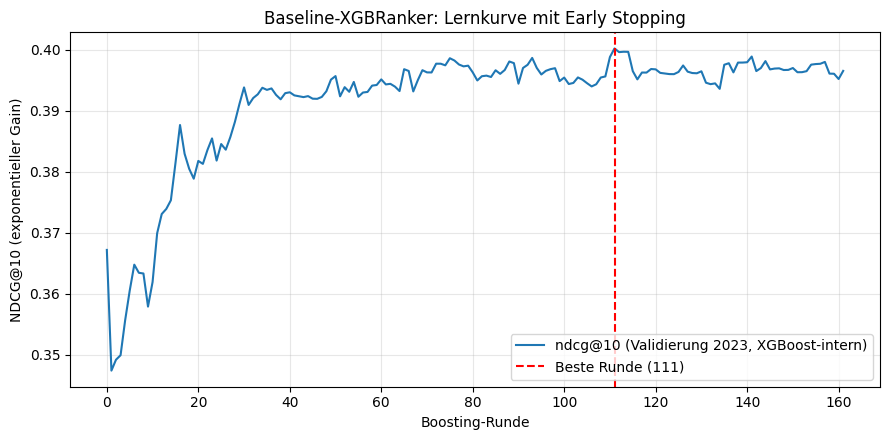

In [5]:
start_time = time.time()

ranker_base = XGBRanker(
    objective="rank:ndcg",              # LambdaMART mit |Delta-NDCG|-Gewichtung
    eval_metric="ndcg@10",              # gruppenbewusstes Stopp-/Monitoringkriterium
    lambdarank_pair_method="mean",      # zufälliges Paar-Sampling (kleinere Datensätze)
    lambdarank_num_pair_per_sample=2,   # 2 Vergleichspartner pro Fahrer und Runde
    n_estimators=1000,                  # Obergrenze; effektive Rundenzahl via Early Stopping
    early_stopping_rounds=50,
    learning_rate=0.1,
    max_depth=6,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

ranker_base.fit(
    X_train_enc, y_train_rel,
    qid=qid_train,
    eval_set=[(X_valid_enc, y_valid_rel)],
    eval_qid=[qid_valid],
    verbose=False,
)

duration = time.time() - start_time
eval_history = ranker_base.evals_result()["validation_0"]["ndcg@10"]

print("==================================================================")
print("Baseline-XGBRanker trainiert")
print("==================================================================")
print(f"Trainingszeit                : {duration:.1f} Sekunden")
print(f"Beste Boosting-Runde         : {ranker_base.best_iteration}")
print(f"Internes ndcg@10 (Valid 2023): {eval_history[ranker_base.best_iteration]:.4f}")
print("==================================================================")

# Lernkurve: interne Validierungs-NDCG@10 über die Boosting-Runden
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(eval_history, label="ndcg@10 (Validierung 2023, XGBoost-intern)")
ax.axvline(ranker_base.best_iteration, color="red", linestyle="--",
           label=f"Beste Runde ({ranker_base.best_iteration})")
ax.set_xlabel("Boosting-Runde")
ax.set_ylabel("NDCG@10 (exponentieller Gain)")
ax.set_title("Baseline-XGBRanker: Lernkurve mit Early Stopping")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("../../data/charts", exist_ok=True)
plt.savefig("../../data/charts/xgbranker_baseline_lernkurve.png", dpi=150, bbox_inches="tight")
plt.show()

## Baseline-Evaluation auf der Validierungssaison 2023

Die Baseline wird mit der oben definierten Hilfsfunktion etappenweise bewertet. Zusätzlich wird die Verteilung der Margin-Scores nach wahrer Relevanzstufe visualisiert: Ein brauchbarer Ranker sollte die vier Stufen bereits sichtbar trennen — wobei die Scores wohlgemerkt **keine feste Skala** besitzen (Interpretation nur relativ, innerhalb einer Etappe).

Baseline-XGBRanker | Etappenweise Evaluation (Validierung 2023)
NDCG@5  (sklearn, linearer Gain) : 0.4664
NDCG@10 (sklearn, linearer Gain) : 0.4401
NDCG@20 (sklearn, linearer Gain) : 0.4436
Spearman Rho (Ø pro Etappe)      : 0.3502
Pointwise ROC-AUC (Top-10, gepoolt): 0.7707


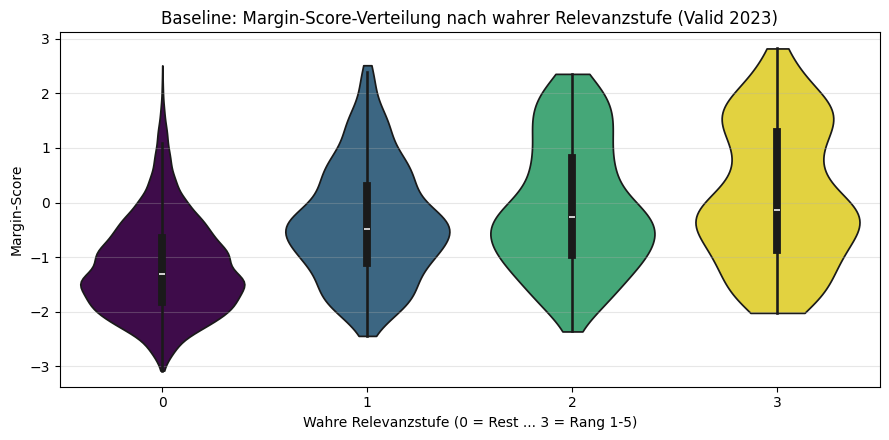

In [6]:
scores_base_valid = ranker_base.predict(X_valid_enc)

metrics_base_valid = evaluate_ranking(
    scores_base_valid,
    y_rank_valid,
    groups_valid,
    y_top10_binary=y_top10_valid,
)

print("==================================================================")
print("Baseline-XGBRanker | Etappenweise Evaluation (Validierung 2023)")
print("==================================================================")
print(f"NDCG@5  (sklearn, linearer Gain) : {metrics_base_valid['ndcg@5']:.4f}")
print(f"NDCG@10 (sklearn, linearer Gain) : {metrics_base_valid['ndcg@10']:.4f}")
print(f"NDCG@20 (sklearn, linearer Gain) : {metrics_base_valid['ndcg@20']:.4f}")
print(f"Spearman Rho (Ø pro Etappe)      : {metrics_base_valid['spearman']:.4f}")
print(f"Pointwise ROC-AUC (Top-10, gepoolt): {metrics_base_valid['roc_auc_top10']:.4f}")
print("==================================================================")

# Score-Verteilung nach wahrer Relevanzstufe
df_score_dist = pd.DataFrame({
    "Margin-Score": scores_base_valid,
    "Wahre Relevanz": y_valid_rel.values,
})
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.violinplot(
    data=df_score_dist, x="Wahre Relevanz", y="Margin-Score",
    hue="Wahre Relevanz", palette="viridis", legend=False, cut=0, ax=ax,
)
ax.set_title("Baseline: Margin-Score-Verteilung nach wahrer Relevanzstufe (Valid 2023)")
ax.set_xlabel("Wahre Relevanzstufe (0 = Rest ... 3 = Rang 1-5)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Automatisiertes Hyperparameter-Tuning
## Grid Search über Baum- und LambdaMART-Parameter

Wie beim EBM (`10-01`) erfolgt das Tuning als systematische Grid Search mit `itertools.product`; die Modellauswahl geschieht **ausschließlich auf der Validierungssaison 2023**, die Testsaisons 2024/2025 bleiben unberührt (Schutz vor Data Leakage im Auswahlprozess).

**Suchraum.** Getunt werden drei Parameterfamilien:

- **Baumkomplexität und Lernverhalten**: `max_depth` (flachere Bäume regularisieren; bei 17 Features sind sehr tiefe Bäume selten nötig) und `learning_rate` (kleinere Schrittweite + Early Stopping = mehr, aber vorsichtigere Boosting-Runden). Der Suchraum umschließt bewusst auch die Baseline-Konfiguration (`max_depth=6`), damit die Modellauswahl fair ist und das Tuning nicht an der Baseline "vorbeisucht".
- **Stochastische Regularisierung**: `subsample`/`colsample_bytree` werden als gemeinsames Paar getestet — (0.8, 0.8) als bewährte Regularisierungswerte (vgl. Grid des XGBoost-Regressors in `11-00`) gegen (1.0, 1.0) ohne Subsampling.
- **LambdaMART-Paarbildung**: die Kombinationen aus `lambdarank_pair_method` und `lambdarank_num_pair_per_sample`. Für `mean` werden 2/4/8 Paare pro Fahrer getestet (mehr Paare = mehr effective pairs, aber längeres Training); für `topk` ein Trunkierungslevel von 13 (leicht oberhalb des Ziel-Cutoffs $k=10$, gemäß Dokumentationsempfehlung).

Die Early-Stopping-Geduld wird im Tuning auf 100 Runden erhöht: Die interne `ndcg@10`-Validierungsmetrik ist bei Ranking-Problemen deutlich verrauschter als etwa ein Log-Loss, sodass zu knappe Geduld Konfigurationen mit langsamem Start vorzeitig abbrechen kann. Da eine einzelne Ranker-Anpassung auf diesem Datensatz nur Sekunden dauert, ist der Mehraufwand vernachlässigbar.

**Auswahlkriterium.** Primäre Metrik ist das **mittlere etappenweise NDCG@10** (sklearn, linearer Gain) auf der Saison 2023 — dieselbe Definition wie in der finalen Evaluation. Die gepoolte **ROC-AUC** auf dem Top-10-Target wird für jede Kombination mitprotokolliert, um den Bezug zur Modellauswahl von EBM (Top-10-AUC) und TabPFN herzustellen; als *Auswahlkriterium* wäre sie beim Ranker jedoch ungeeignet, da sie die nicht kalibrierten Score-Niveaus verschiedener Etappen vermischt, während NDCG@10 die Sortierung innerhalb der Etappen misst — genau das, was der Ranker leisten soll.

In [7]:
model_path = "../../data/models"
os.makedirs(model_path, exist_ok=True)

# Suchraum: Baumparameter x Regularisierung x LambdaMART-Paarbildung
# (pair_method und num_pair werden als Tupel kombiniert, da die Semantik
#  von lambdarank_num_pair_per_sample von der Methode abhängt:
#  mean = Paare pro Fahrer, topk = Trunkierungslevel;
#  subsample und colsample_bytree werden als gemeinsames Paar variiert)
grid_parameters = {
    "max_depth": [3, 5, 6, 8],
    "learning_rate": [0.03, 0.1],
    "pair_config": [("mean", 2), ("mean", 4), ("mean", 8), ("topk", 13)],
    "sample_config": [(0.8, 0.8), (1.0, 1.0)],
}

keys, values = zip(*grid_parameters.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

tuning_results = []
best_model_tracker = {"ndcg10_valid": 0.0, "model": None, "config": None}

print(f"Starte XGBRanker-Grid-Search ({len(experiments)} Kombinationen)...")
print("==========================================================================================")

global_start_time = time.time()

for idx, config in enumerate(experiments, 1):
    pair_method, num_pair = config["pair_config"]
    subsample, colsample = config["sample_config"]
    print(f"-->LAUF {idx}/{len(experiments)} | depth={config['max_depth']}, "
          f"lr={config['learning_rate']}, pairs={pair_method}/{num_pair}, "
          f"subsample={subsample}")

    start_run = time.time()

    ranker_tune = XGBRanker(
        objective="rank:ndcg",
        eval_metric="ndcg@10",
        lambdarank_pair_method=pair_method,
        lambdarank_num_pair_per_sample=num_pair,
        n_estimators=1000,
        early_stopping_rounds=100,
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        subsample=subsample,
        colsample_bytree=colsample,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )
    ranker_tune.fit(
        X_train_enc, y_train_rel,
        qid=qid_train,
        eval_set=[(X_valid_enc, y_valid_rel)],
        eval_qid=[qid_valid],
        verbose=False,
    )

    # Bewertung auf der Validierungssaison 2023 (sklearn-Konventionen wie 10-01)
    scores_valid = ranker_tune.predict(X_valid_enc)
    m = evaluate_ranking(scores_valid, y_rank_valid, groups_valid, y_top10_binary=y_top10_valid)

    duration_run = time.time() - start_run
    print(f"   NDCG@10: {m['ndcg@10']:.4f} | NDCG@5: {m['ndcg@5']:.4f} | "
          f"ROC-AUC: {m['roc_auc_top10']:.4f} | Spearman: {m['spearman']:.4f} | "
          f"Runden: {ranker_tune.best_iteration} | Zeit: {duration_run:.1f}s")
    print("------------------------------------------------------------------------------------------")

    tuning_results.append({
        "max_depth": config["max_depth"],
        "learning_rate": config["learning_rate"],
        "pair_method": pair_method,
        "num_pair": num_pair,
        "subsample": subsample,
        "best_iteration": ranker_tune.best_iteration,
        "ndcg@5": m["ndcg@5"],
        "ndcg@10": m["ndcg@10"],
        "ndcg@20": m["ndcg@20"],
        "spearman": m["spearman"],
        "roc_auc_top10": m["roc_auc_top10"],
        "dauer_sek": duration_run,
    })

    # Tracking des besten Modells anhand des primären Kriteriums NDCG@10
    if m["ndcg@10"] > best_model_tracker["ndcg10_valid"]:
        best_model_tracker["ndcg10_valid"] = m["ndcg@10"]
        best_model_tracker["model"] = ranker_tune
        best_model_tracker["config"] = config

total_duration = time.time() - global_start_time
print(f"\nTuning beendet! Gesamte Rechenzeit: {total_duration/60:.1f} Minuten")

# Gewinner-Modell speichern (Pickle analog zum EBM-Ensemble;
# alternativ bietet xgboost ranker.save_model('...json') als versionsstabiles Format)
full_save_path = os.path.join(model_path, "xgbranker_best.pkl")
with open(full_save_path, "wb") as f:
    pickle.dump(best_model_tracker["model"], f)

best_cfg = best_model_tracker["config"]
print("==========================================================================================")
print(f"GEWINNER-SETUP (Max NDCG@10 Valid = {best_model_tracker['ndcg10_valid']:.4f}):")
print(f"[max_depth: {best_cfg['max_depth']}, learning_rate: {best_cfg['learning_rate']}, "
      f"pair_config: {best_cfg['pair_config']}, sample_config: {best_cfg['sample_config']}]")
print(f"--Modell gesichert unter: {full_save_path}")
print("==========================================================================================")

# Vollständige Ergebnistabelle, sortiert nach dem Auswahlkriterium
df_tuning = pd.DataFrame(tuning_results).sort_values("ndcg@10", ascending=False).reset_index(drop=True)
print(df_tuning.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Starte XGBRanker-Grid-Search (64 Kombinationen)...
-->LAUF 1/64 | depth=3, lr=0.03, pairs=mean/2, subsample=0.8


   NDCG@10: 0.2693 | NDCG@5: 0.2636 | ROC-AUC: 0.7043 | Spearman: 0.2643 | Runden: 0 | Zeit: 0.7s
------------------------------------------------------------------------------------------
-->LAUF 2/64 | depth=3, lr=0.03, pairs=mean/2, subsample=1.0


   NDCG@10: 0.2654 | NDCG@5: 0.2550 | ROC-AUC: 0.7040 | Spearman: 0.2647 | Runden: 0 | Zeit: 0.7s
------------------------------------------------------------------------------------------
-->LAUF 3/64 | depth=3, lr=0.03, pairs=mean/4, subsample=0.8


   NDCG@10: 0.2708 | NDCG@5: 0.2639 | ROC-AUC: 0.7049 | Spearman: 0.2652 | Runden: 0 | Zeit: 0.9s
------------------------------------------------------------------------------------------
-->LAUF 4/64 | depth=3, lr=0.03, pairs=mean/4, subsample=1.0


   NDCG@10: 0.2714 | NDCG@5: 0.2659 | ROC-AUC: 0.7073 | Spearman: 0.2754 | Runden: 0 | Zeit: 0.8s
------------------------------------------------------------------------------------------
-->LAUF 5/64 | depth=3, lr=0.03, pairs=mean/8, subsample=0.8


...

   NDCG@10: 0.4379 | NDCG@5: 0.4580 | ROC-AUC: 0.7645 | Spearman: 0.3334 | Runden: 39 | Zeit: 1.6s
------------------------------------------------------------------------------------------
-->LAUF 61/64 | depth=8, lr=0.1, pairs=mean/8, subsample=0.8


   NDCG@10: 0.4436 | NDCG@5: 0.4559 | ROC-AUC: 0.7753 | Spearman: 0.3451 | Runden: 97 | Zeit: 2.8s
------------------------------------------------------------------------------------------
-->LAUF 62/64 | depth=8, lr=0.1, pairs=mean/8, subsample=1.0


   NDCG@10: 0.4524 | NDCG@5: 0.4735 | ROC-AUC: 0.7819 | Spearman: 0.3492 | Runden: 228 | Zeit: 4.5s
------------------------------------------------------------------------------------------
-->LAUF 63/64 | depth=8, lr=0.1, pairs=topk/13, subsample=0.8


   NDCG@10: 0.3706 | NDCG@5: 0.3921 | ROC-AUC: 0.7223 | Spearman: 0.2802 | Runden: 0 | Zeit: 1.2s
------------------------------------------------------------------------------------------
-->LAUF 64/64 | depth=8, lr=0.1, pairs=topk/13, subsample=1.0


   NDCG@10: 0.3615 | NDCG@5: 0.4080 | ROC-AUC: 0.7204 | Spearman: 0.2602 | Runden: 0 | Zeit: 1.3s
------------------------------------------------------------------------------------------

Tuning beendet! Gesamte Rechenzeit: 2.3 Minuten
GEWINNER-SETUP (Max NDCG@10 Valid = 0.4524):
[max_depth: 8, learning_rate: 0.1, pair_config: ('mean', 8), sample_config: (1.0, 1.0)]
--Modell gesichert unter: ../../data/models/xgbranker_best.pkl
 max_depth  learning_rate pair_method  num_pair  subsample  best_iteration  ndcg@5  ndcg@10  ndcg@20  spearman  roc_auc_top10  dauer_sek
         8         0.1000        mean         8     1.0000             228  0.4735   0.4524   0.4588    0.3492         0.7819     4.5249
         8         0.0300        mean         2     0.8000             484  0.4840   0.4493   0.4486    0.3493         0.7796     5.1722
         8         0.1000        mean         2     0.8000              67  0.4797   0.4472   0.4474    0.3426         0.7715     1.5647
         8        

## Interpretation der Tuning-Ergebnisse

**Gewinner-Konfiguration.** Das beste Setup auf der Validierungssaison 2023 ist `max_depth=8`, `learning_rate=0.1`, `lambdarank_pair_method='mean'` mit 8 Paaren pro Fahrer und **ohne** Subsampling (`subsample=colsample_bytree=1.0`), trainiert über 228 Boosting-Runden: **NDCG@10 = 0.4524** (Baseline: 0.4401), ROC-AUC 0.7819.

Zentrale Befunde aus der Ergebnistabelle:

- **`mean` schlägt `topk`.** Die Spitze der Tabelle wird durchgehend von `mean`-Konfigurationen besetzt; die beste `topk`-Variante landet im Mittelfeld. Das bestätigt die Empfehlung der XGBoost-Dokumentation, bei kleineren Datensätzen das zufällige Paar-Sampling zu verwenden — die breiter gestreuten effective pairs generalisieren besser als die Top-$k$-Fokussierung.
- **Mehr Paare helfen — mit Grenznutzen.** Bei `max_depth ≥ 5` liegen `mean/4` und `mean/8` fast durchgehend vor `mean/2`; der Sprung von 4 auf 8 Paare bringt nur noch wenig. Mehr Paare bedeuten mehr effective pairs pro Runde, kosten aber proportional Rechenzeit.
- **Tiefe Bäume gewinnen die Validierung.** `max_depth=8` dominiert die vorderen Plätze, `max_depth=3` scheitert vollständig: **Alle** depth-3-Läufe stoppen bereits in Runde 0 (die interne `ndcg@10`-Validierungsmetrik übertrifft ihren Startwert innerhalb von 100 Runden nie) und bleiben damit faktisch Ein-Baum-Modelle mit NDCG@10 ≈ 0.27. Das ist eine dokumentationswürdige Eigenheit des Early Stopping mit verrauschten Ranking-Metriken: Schwache Lerner kommen aus dem Startloch nicht heraus, bevor die Geduld abläuft. Die *finale* Bewertung dieser Präferenz für tiefe Bäume erfolgt allerdings erst auf dem Testset (siehe nächster Abschnitt — dort relativiert sich das Bild deutlich).
- **Lernrate ist sekundär.** `learning_rate=0.03` und `0.1` erscheinen beide in den Top-Konfigurationen; die kleinere Lernrate wird erwartungsgemäß durch mehr Boosting-Runden kompensiert (z. B. 484 vs. 67 Runden bei ansonsten gleichem Setup).
- **NDCG@10 und gepoolte ROC-AUC laufen grob, aber nicht exakt parallel.** Die Rangfolgen der beiden Spalten stimmen an der Spitze weitgehend überein, tauschen aber im Mittelfeld mehrfach die Plätze — etappenweise Sortierqualität und gepoolte pointwise Trennschärfe messen verwandte, aber nicht identische Eigenschaften.

# Finale Out-of-Sample-Evaluation auf den Testsaisons 2024/2025

Nach Abschluss der Modellentwicklung erfolgt die finale Evaluation auf den vollständig unberührten Testsaisons 2024 und 2025 — verglichen werden der **untunede Baseline-Ranker** und das **getunte Gewinner-Modell** (analog zum Vergleich "1D-Baseline vs. GA²M" im EBM-Notebook).

Der folgende Codeblock repliziert **exakt** den finalen Metrik-Block aus `10-01` (dort ebenfalls dokumentiert als Referenz für TabPFN in `12-03`), damit alle vier Modelle des Projekts mit identisch definierten Zahlen verglichen werden können:

- **Pointwise ROC-AUC** des Scores gegen das binäre Top-10-Target (gepoolt über alle Zeilen),
- **NDCG@5/10/20** pro Etappe via `sklearn.metrics.ndcg_score` (linearer Gain), gemittelt; Etappen ohne relevante Fahrer werden übersprungen,
- **MAP@10**: Average Precision der prognostizierten Top-10 pro Etappe (Division durch 10), gemittelt,
- **Winner-Hit-Rates @1/5/10/20**: Anteil der Etappen, in denen der reale Sieger unter den Top-$k$ der Prognose liegt,
- **Spearman Rho** pro Etappe (Score vs. negierter Realrang), gemittelt.

Der einzige inhaltliche Unterschied zum EBM-Block: Die Score-Spalten stammen nicht aus einer Wahrscheinlichkeits-Summe, sondern sind die Margin-Scores der beiden Ranker.

In [8]:
# FINALE OUT-OF-SAMPLE RANKING-EVALUATION (2024/2025)
# 1. TEST-EVALUATION VORBEREITEN
df_test_eval = pd.DataFrame(
    {
        "stage_id": meta_test["stage_id"].values,
        "y_true_rank": np.asarray(y_rank_test),
    }
)

# Globales, binäres Top-10-Target für die Pointwise-Auswertung
y_test_top10_binary = y_top10_test.astype(int)


# 2. BASELINE-RANKER AUF TESTDATEN ANWENDEN
print("Berechne Vorhersagen des Baseline-Rankers...")
df_test_eval["score_baseline"] = ranker_base.predict(X_test_enc)
auc_baseline_test = roc_auc_score(y_test_top10_binary, df_test_eval["score_baseline"])


# 3. GETUNTES GEWINNER-MODELL LADEN UND ANWENDEN
print("Lade besten getunten XGBRanker...")
with open(os.path.join(model_path, "xgbranker_best.pkl"), "rb") as f:
    ranker_tuned = pickle.load(f)

df_test_eval["score_tuned"] = ranker_tuned.predict(X_test_enc)
auc_tuned_test = roc_auc_score(y_test_top10_binary, df_test_eval["score_tuned"])


# ==============================================================================
# 4. ETAPPENWEISE LISTWISE-EVALUATION (identisch zu Notebook 10-01)
# ==============================================================================
print("Starte etappenweise Ranking-Evaluation...")

ndcg_base = {5: [], 10: [], 20: []}
ndcg_tuned = {5: [], 10: [], 20: []}

ap_base = []
ap_tuned = []

winner_hits_base = {1: 0, 5: 0, 10: 0, 20: 0}
winner_hits_tuned = {1: 0, 5: 0, 10: 0, 20: 0}

spearman_base = []
spearman_tuned = []

valid_stage_counter = 0
winner_stage_counter = 0

for stage_id, group in df_test_eval.groupby("stage_id"):
    group = group.dropna(subset=["y_true_rank", "score_baseline", "score_tuned"]).copy()
    if group.empty:
        continue

    valid_stage_counter += 1
    group["true_relevance"] = group["y_true_rank"].apply(rank_to_relevance)

    y_true_relevance = group["true_relevance"].values.reshape(1, -1)
    scores_base = group["score_baseline"].values.reshape(1, -1)
    scores_tuned = group["score_tuned"].values.reshape(1, -1)

    if np.nansum(y_true_relevance) > 0:
        for k in [5, 10, 20]:
            ndcg_base[k].append(ndcg_score(y_true_relevance, scores_base, k=k))
            ndcg_tuned[k].append(ndcg_score(y_true_relevance, scores_tuned, k=k))

    # Sortierte Listen für Hits und Average Precision vorbereiten
    base_sorted = group.sort_values("score_baseline", ascending=False).reset_index(drop=True)
    tuned_sorted = group.sort_values("score_tuned", ascending=False).reset_index(drop=True)

    # ---- BERECHNUNG AVERAGE PRECISION (AP@10) PRO ETAPPE ----
    relevant_found_base = 0
    precision_sum_base = 0.0
    for idx, row in base_sorted.head(10).iterrows():
        if row["y_true_rank"] <= 10:
            relevant_found_base += 1
            precision_sum_base += relevant_found_base / (idx + 1)
    ap_base.append(precision_sum_base / 10.0)

    relevant_found_tuned = 0
    precision_sum_tuned = 0.0
    for idx, row in tuned_sorted.head(10).iterrows():
        if row["y_true_rank"] <= 10:
            relevant_found_tuned += 1
            precision_sum_tuned += relevant_found_tuned / (idx + 1)
    ap_tuned.append(precision_sum_tuned / 10.0)

    # ---- WINNER-HIT-RATES ----
    has_winner = (group["y_true_rank"] == 1).any()
    if has_winner:
        winner_stage_counter += 1

        winner_pos_base = base_sorted.index[base_sorted["y_true_rank"] == 1].tolist()
        winner_pos_tuned = tuned_sorted.index[tuned_sorted["y_true_rank"] == 1].tolist()

        if winner_pos_base:
            pos_base = winner_pos_base[0] + 1
            for k in [1, 5, 10, 20]:
                if pos_base <= k:
                    winner_hits_base[k] += 1

        if winner_pos_tuned:
            pos_tuned = winner_pos_tuned[0] + 1
            for k in [1, 5, 10, 20]:
                if pos_tuned <= k:
                    winner_hits_tuned[k] += 1

    # ---- SPEARMAN ----
    if group["score_baseline"].nunique() > 1 and group["y_true_rank"].nunique() > 1:
        rho_b, _ = spearmanr(group["score_baseline"], -group["y_true_rank"])
        if not np.isnan(rho_b):
            spearman_base.append(rho_b)

    if group["score_tuned"].nunique() > 1 and group["y_true_rank"].nunique() > 1:
        rho_t, _ = spearmanr(group["score_tuned"], -group["y_true_rank"])
        if not np.isnan(rho_t):
            spearman_tuned.append(rho_t)


# ==============================================================================
# 5. VERGLEICHSTABELLE ERSTELLEN & DRUCKEN
# ==============================================================================
summary_data = {
    "Metrik": [
        "Pointwise ROC-AUC (Margin-Score)",
        "NDCG@5",
        "NDCG@10",
        "NDCG@20",
        "Mean Average Precision (MAP@10)",
        "Winner Hit@1",
        "Winner Hit@5",
        "Winner Hit@10",
        "Winner Hit@20",
        "Spearman Rho",
    ],
    "XGBRanker Baseline": [
        auc_baseline_test,
        np.mean(ndcg_base[5]),
        np.mean(ndcg_base[10]),
        np.mean(ndcg_base[20]),
        np.mean(ap_base),
        winner_hits_base[1] / winner_stage_counter,
        winner_hits_base[5] / winner_stage_counter,
        winner_hits_base[10] / winner_stage_counter,
        winner_hits_base[20] / winner_stage_counter,
        np.mean(spearman_base),
    ],
    "XGBRanker Tuned": [
        auc_tuned_test,
        np.mean(ndcg_tuned[5]),
        np.mean(ndcg_tuned[10]),
        np.mean(ndcg_tuned[20]),
        np.mean(ap_tuned),
        winner_hits_tuned[1] / winner_stage_counter,
        winner_hits_tuned[5] / winner_stage_counter,
        winner_hits_tuned[10] / winner_stage_counter,
        winner_hits_tuned[20] / winner_stage_counter,
        np.mean(spearman_tuned),
    ],
}

df_comparison = pd.DataFrame(summary_data)


def format_row(row, col):
    metric = row["Metrik"]
    value = row[col]
    if "ROC-AUC" in metric or "Spearman" in metric or "Precision" in metric:
        return f"{value:.4f}"
    return f"{value*100:.2f}%"


df_print = df_comparison.copy()
df_print["XGBRanker Baseline"] = df_comparison.apply(lambda r: format_row(r, "XGBRanker Baseline"), axis=1)
df_print["XGBRanker Tuned"] = df_comparison.apply(lambda r: format_row(r, "XGBRanker Tuned"), axis=1)

print("\n==================================================================")
print("FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)")
print("==================================================================")
print(f"Ausgewertete Etappen         : {valid_stage_counter}")
print(f"Etappen mit Sieger-Wertung   : {winner_stage_counter}")
print("------------------------------------------------------------------")
print(df_print.to_string(index=False))
print("==================================================================")

Berechne Vorhersagen des Baseline-Rankers...
Lade besten getunten XGBRanker...
Starte etappenweise Ranking-Evaluation...



FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)
Ausgewertete Etappen         : 112
Etappen mit Sieger-Wertung   : 111
------------------------------------------------------------------
                          Metrik XGBRanker Baseline XGBRanker Tuned
Pointwise ROC-AUC (Margin-Score)             0.7757          0.7786
                          NDCG@5             41.31%          39.64%
                         NDCG@10             39.30%          38.30%
                         NDCG@20             41.73%          41.39%
 Mean Average Precision (MAP@10)             0.1748          0.1686
                    Winner Hit@1             18.92%          16.22%
                    Winner Hit@5             42.34%          36.94%
                   Winner Hit@10             52.25%          48.65%
                   Winner Hit@20             63.06%          65.77%
                    Spearman Rho             0.3125          0.3067


## Modellvergleich: XGBRanker vs. EBM vs. TabPFN vs. XGBoost-Regressor

Da alle Modelle mit **identisch definierten Metriken** auf denselben Testsaisons evaluiert werden, lassen sich die Ergebnisse direkt gegenüberstellen. Die EBM-Werte stammen aus der finalen Evaluation in `10-01`; die Spalten für TabPFN (`12-03`) und den XGBoost-Regressor (`11-00`) sind nach deren finalen Läufen zu ergänzen.

| Metrik | XGBRanker Baseline | XGBRanker Tuned | EBM Tuned (GA²M, aus `10-01`) | TabPFN (aus `12-03`) | XGBoost Regressor (aus `11-00`) |
| :--- | ---: | ---: | ---: | ---: | ---: |
| Pointwise ROC-AUC | 0.7757 | **0.7786** | 0.7757 | *(eintragen)* | — |
| NDCG@5 | **41.31 %** | 39.64 % | 39.24 % | *(eintragen)* | *(eintragen)* |
| NDCG@10 | **39.30 %** | 38.30 % | 38.03 % | *(eintragen)* | *(eintragen)* |
| NDCG@20 | **41.73 %** | 41.39 % | 40.99 % | *(eintragen)* | *(eintragen)* |
| MAP@10 | **0.1748** | 0.1686 | 0.1667 | *(eintragen)* | — |
| Winner Hit@1 | **18.92 %** | 16.22 % | 16.22 % | *(eintragen)* | — |
| Winner Hit@5 | **42.34 %** | 36.94 % | 40.54 % | *(eintragen)* | — |
| Winner Hit@10 | **52.25 %** | 48.65 % | 51.35 % | *(eintragen)* | — |
| Winner Hit@20 | 63.06 % | 65.77 % | **67.57 %** | *(eintragen)* | — |
| Spearman Rho | **0.3125** | 0.3067 | 0.3042 | *(eintragen)* | *(eintragen)* |

**Interpretation:**

1. **Der zentrale — und unerwartete — Befund ist der Vergleich der beiden Ranker-Varianten untereinander:** Das getunte Modell gewinnt die Validierungssaison 2023 klar (NDCG@10 0.4524 vs. 0.4401), fällt aber auf den Testsaisons 2024/2025 in fast allen etappenweisen Metriken hinter die eigene Baseline zurück. Die tiefen Bäume (`max_depth=8`), die die Validierung dominierten, generalisieren schlechter als die moderatere Baseline-Konfiguration (`max_depth=6`, `mean/2`, ohne Subsampling). Das ist ein Lehrbuchbeispiel für **Auswahl-Overfitting auf eine einzelne Validierungssaison**: Mit nur 57 Validierungsetappen ist das Auswahlkriterium selbst verrauscht, und die Auswahl passt sich an die Eigenheiten der Saison 2023 an. Methodisch bleibt der getunte Ranker das Ergebnis der vorab festgelegten Auswahlregel — die Baseline-Spalte dokumentiert die Diskrepanz transparent. (Die Testdaten dürfen nachträglich *nicht* zur Modellauswahl herangezogen werden, sonst entstünde genau das Data Leakage, das das chronologische Design verhindern soll.)
2. **Vergleich mit dem EBM:** Beide Ranker-Varianten erreichen bei den Kernmetriken der Sortierqualität (NDCG@5/10/20, MAP@10, Spearman Rho) das Niveau des getunten GA²M-Ensembles oder übertreffen es; die Baseline zusätzlich bei Winner Hit@1/5/10 (Hit@1: 18.92 % vs. 16.22 %). Das native Learning-to-Rank-Ziel zahlt sich damit messbar aus — aber moderat: Die identische Informationslage (dieselben 17 Features) begrenzt alle Modelle gleichermaßen; das Trainingsziel verschiebt die Qualität um wenige Prozentpunkte, ersetzt aber keine fehlende Information. Beim erweiterten Favoritenkreis (Hit@20) bleibt das EBM vorn.
3. **Gepoolte ROC-AUC:** Obwohl der Ranker globale Score-Kalibrierung nie optimiert hat, erreicht seine Baseline exakt das EBM-Niveau (0.7757), das getunte Modell liegt leicht darüber (0.7786). Die theoretische Sorge, unkalibrierte Margin-Scores würden die gepoolte AUC strukturell benachteiligen, bestätigt sich empirisch nicht — die gelernte Score-Funktion ist über Etappen hinweg hinreichend stabil.
4. **Transparenz-Trade-off:** Der Qualitätsvorsprung des Rankers gegenüber dem EBM ist real, aber klein. Ob er den Verzicht auf die Glass-Box-Eigenschaft rechtfertigt, hängt vom Einsatzzweck ab — die folgenden SHAP-Analysen zeigen, wie viel Transparenz sich post-hoc zurückgewinnen lässt.

# Interpretation des getunten XGBRankers

## Native Feature Importances (gain, weight, cover)

Als erster, schneller Blick auf das Modell werden die drei eingebauten Importance-Maße verglichen (Definitionen s. Einleitung). Die `gain`-Wichtigkeit ist die aussagekräftigste der drei; Divergenzen zwischen den Maßen (z. B. ein Feature mit vielen Splits, aber geringem Gain) sind selbst diagnostisch interessant. Zu beachten bleiben die bekannten Verzerrungen: reine Trainingssicht, willkürliche Aufteilung zwischen korrelierten Features, keine Effektrichtung.

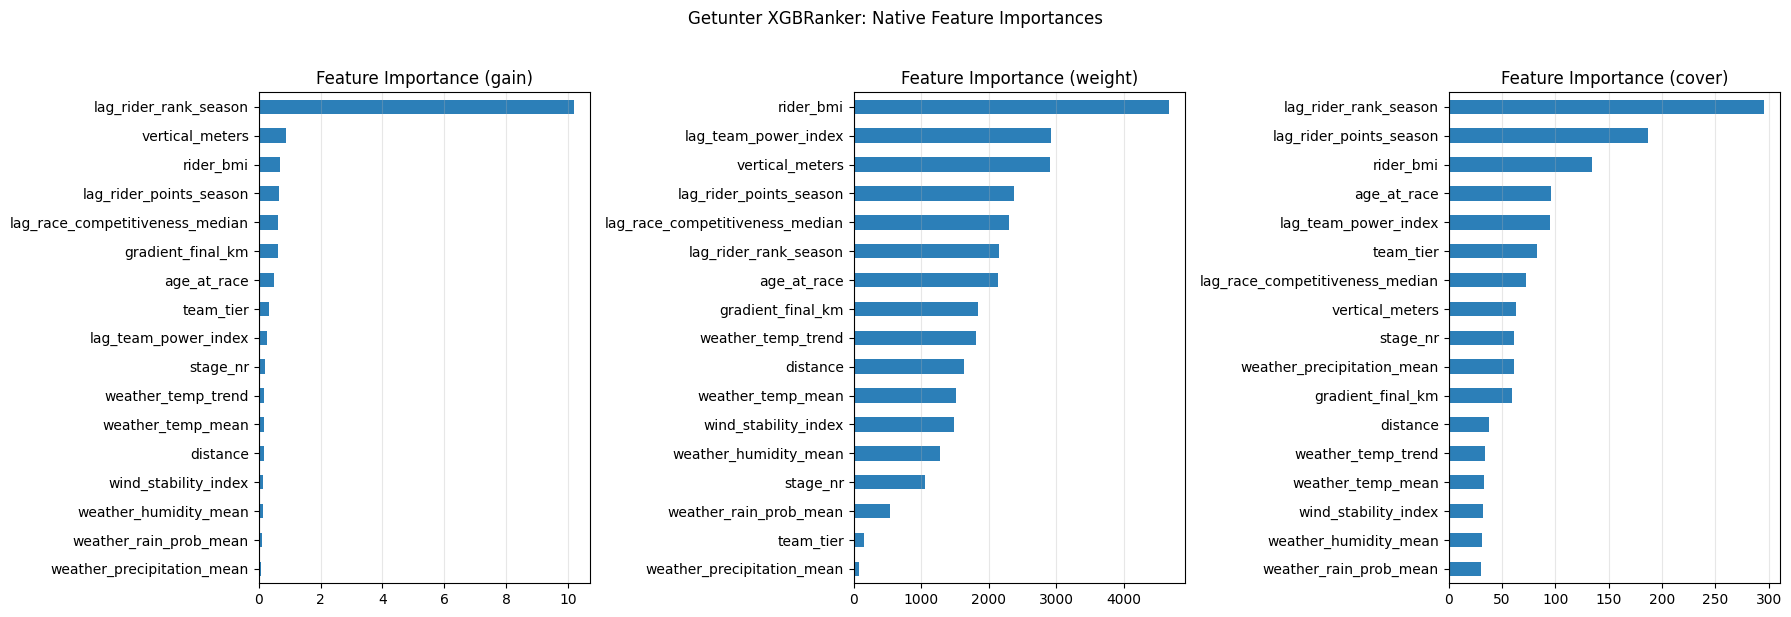

In [9]:
importance_types = ["gain", "weight", "cover"]
booster = ranker_tuned.get_booster()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, imp_type in zip(axes, importance_types):
    imp = booster.get_score(importance_type=imp_type)
    df_imp = (
        pd.Series(imp, name=imp_type)
        .reindex(X_train_enc.columns)   # fehlende Features (nie gesplittet) -> NaN
        .fillna(0.0)
        .sort_values()
    )
    df_imp.plot(kind="barh", ax=ax, color="#2c7fb8")
    ax.set_title(f"Feature Importance ({imp_type})")
    ax.grid(alpha=0.3, axis="x")

plt.suptitle("Getunter XGBRanker: Native Feature Importances", y=1.02)
plt.tight_layout()
plt.savefig("../../data/charts/xgbranker_native_importances.png", dpi=150, bbox_inches="tight")
plt.show()

## Globale SHAP-Analyse

Der `TreeExplainer` berechnet exakte SHAP-Werte auf dem **Margin-Score**. Die Analyse erfolgt auf den Testdaten (2024/2025), also auf der Datenverteilung, auf der das Modell auch bewertet wurde.

- Der **Beeswarm-Plot** zeigt pro Feature die Verteilung der SHAP-Werte aller Fahrer, eingefärbt nach Feature-Wert. Er beantwortet gleichzeitig *"Wie wichtig?"* und *"In welche Richtung?"* — z. B. ob hohe `lag_rider_points_season`-Werte den Relevanz-Score systematisch heben.
- Der **Bar-Plot** aggregiert die mittleren absoluten SHAP-Werte zu einem globalen Wichtigkeits-Ranking, das direkt mit der globalen Feature-Importance des EBM (`explain_global()` in `10-01`) verglichen werden kann: Setzen Glass-Box- und Black-Box-Modell auf dieselben Signale?

Additivitäts-Check (max. Abweichung): 3.81e-06


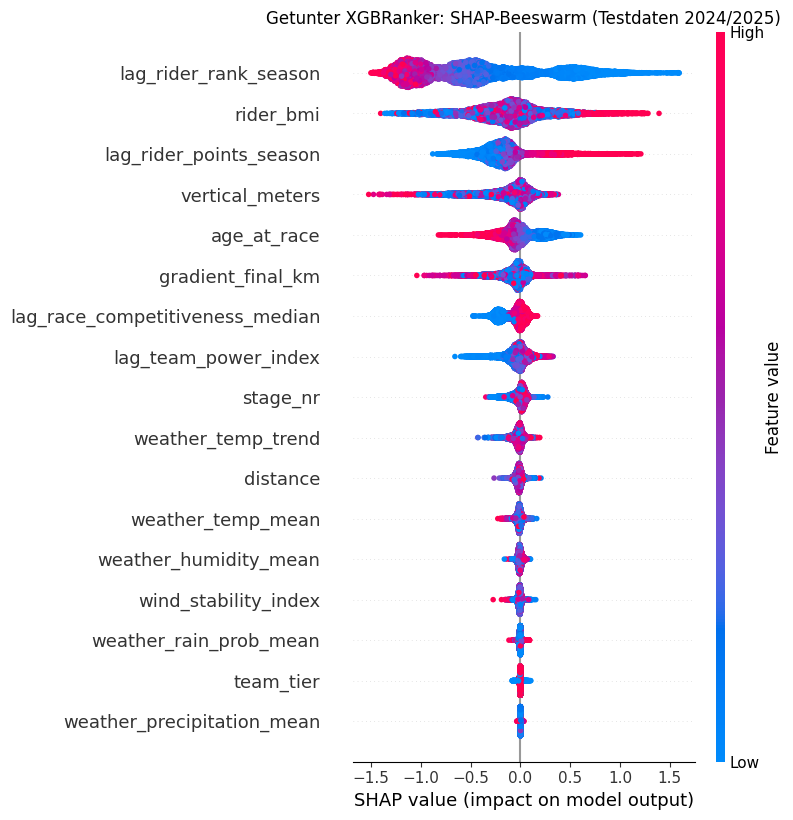

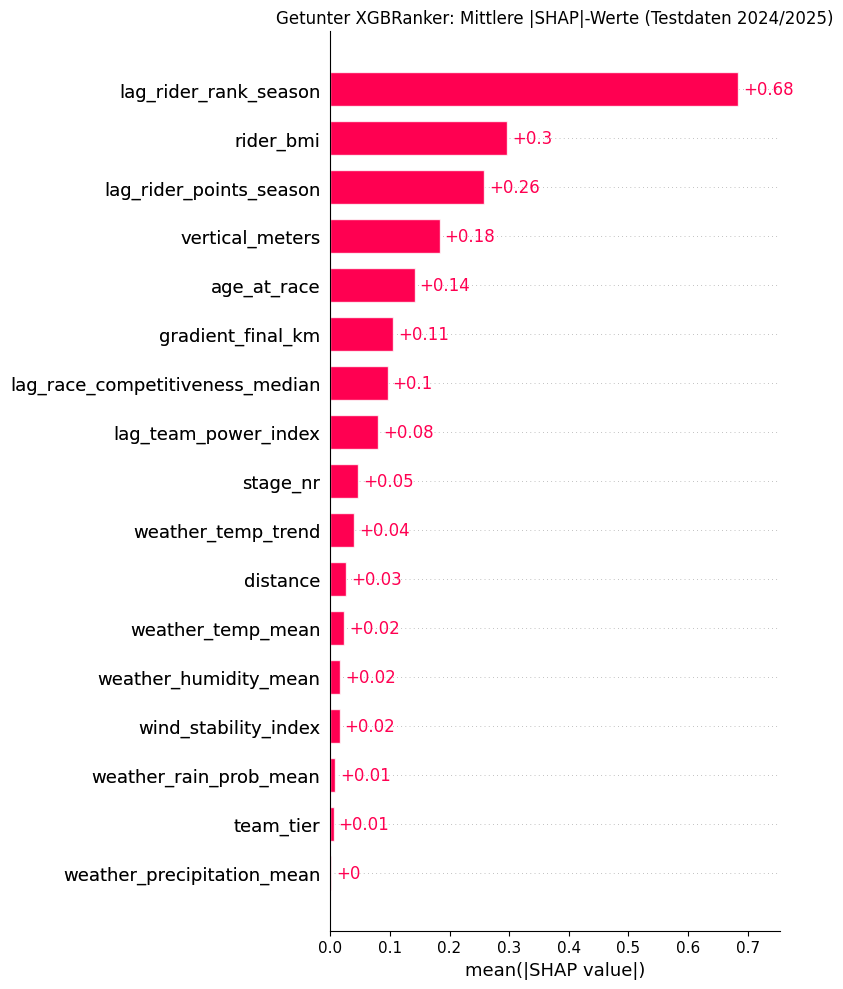

In [10]:
# TreeExplainer auf dem getunten Ranker (erklärt den Margin-Score)
explainer = shap.TreeExplainer(ranker_tuned)

# SHAP-Explanation auf den Testdaten berechnen
# (TreeExplainer ist exakt und schnell; bei Laufzeitproblemen kann alternativ
#  eine Zufallsstichprobe von z. B. 5.000 Zeilen verwendet werden)
shap_explanation = explainer(X_test_enc)

# Kontrolle der Additivität: Basiswert + Summe der SHAP-Werte = Margin-Score
scores_check = ranker_tuned.predict(X_test_enc)
max_abs_err = np.abs(
    shap_explanation.values.sum(axis=1) + shap_explanation.base_values - scores_check
).max()
print(f"Additivitäts-Check (max. Abweichung): {max_abs_err:.2e}")

# Globaler Beeswarm-Plot: Wichtigkeit + Effektrichtung
shap.plots.beeswarm(shap_explanation, max_display=17, show=False)
plt.title("Getunter XGBRanker: SHAP-Beeswarm (Testdaten 2024/2025)")
plt.tight_layout()
plt.savefig("../../data/charts/xgbranker_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# Globales Wichtigkeits-Ranking: mittlere absolute SHAP-Werte
shap.plots.bar(shap_explanation, max_display=17, show=False)
plt.title("Getunter XGBRanker: Mittlere |SHAP|-Werte (Testdaten 2024/2025)")
plt.tight_layout()
plt.savefig("../../data/charts/xgbranker_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP-Dependence-Plots: das Post-hoc-Analogon zu den EBM-Shape-Functions

Ein Dependence-Plot trägt für ein Feature den SHAP-Beitrag jedes Fahrers gegen den Feature-Wert ab — die empirische Effektkurve des Black-Box-Modells. Im Unterschied zur EBM-Shape-Function ist die Kurve nicht per Konstruktion eindimensional: Die **vertikale Streuung** bei gleichem Feature-Wert zeigt Interaktionseffekte mit anderen Merkmalen (die Färbung nach dem stärksten Interaktionspartner macht diese sichtbar). Genau hier lässt sich prüfen, ob der Ranker ähnliche Effektformen lernt wie das GA²M — etwa bei den Lag-Features zur Fahrerform.

Top-4-Features nach mittlerem |SHAP|: ['lag_rider_rank_season', 'rider_bmi', 'lag_rider_points_season', 'vertical_meters']


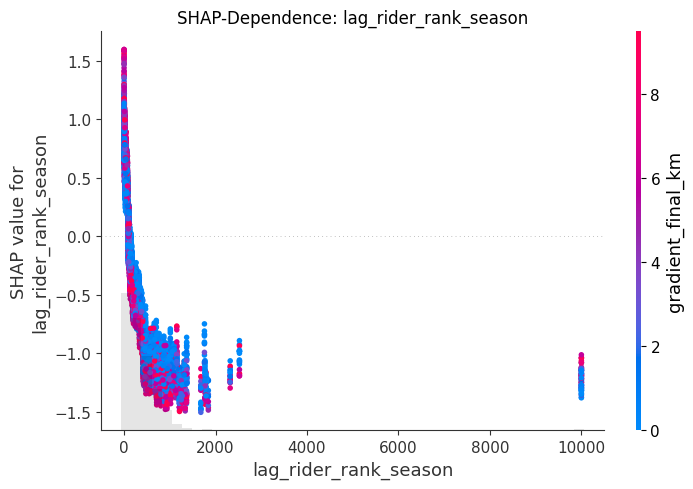

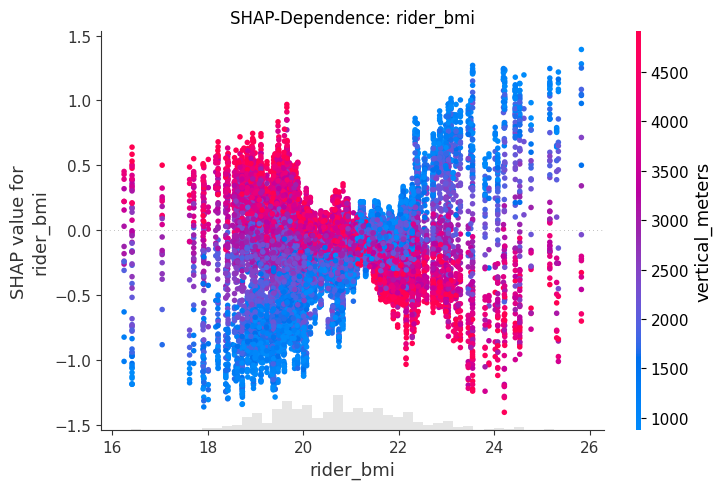

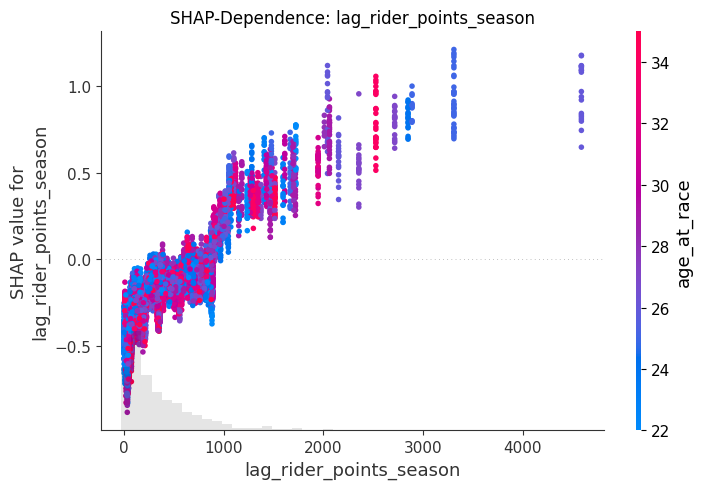

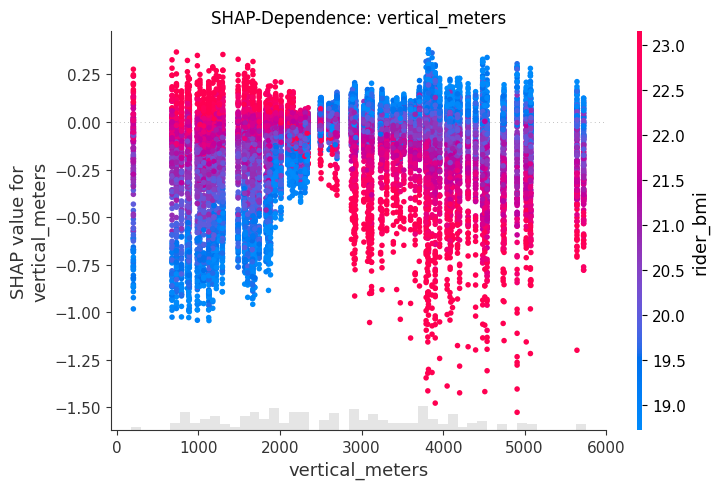

In [11]:
# Die vier global wichtigsten Features (nach mittlerem |SHAP|) auswählen
mean_abs_shap = pd.Series(
    np.abs(shap_explanation.values).mean(axis=0), index=X_test_enc.columns
).sort_values(ascending=False)
top_features = mean_abs_shap.head(4).index.tolist()
print("Top-4-Features nach mittlerem |SHAP|:", top_features)

# Dependence-Plots (Färbung: automatisch stärkster Interaktionspartner)
for feature in top_features:
    shap.plots.scatter(
        shap_explanation[:, feature],
        color=shap_explanation,
        show=False,
    )
    plt.title(f"SHAP-Dependence: {feature}")
    plt.tight_layout()
    plt.savefig(f"../../data/charts/xgbranker_shap_dependence_{feature}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## Lokale SHAP-Erklärungen: einzelne Fahrer einer Etappe

Die Additivität der SHAP-Werte erlaubt **lokale** Erklärungen: Für einen einzelnen Fahrer zerlegt der Waterfall-Plot den Margin-Score vollständig in den Basiswert plus 17 Feature-Beiträge. Als Beispiel wird die höchst- und die niedrigstplatzierte Prognose einer Tour-de-France-2025-Etappe erklärt — die Frage ist jeweils: *Welche Merkmale hebt bzw. senkt der Ranker, um diesen Fahrer innerhalb seiner Etappe nach oben/unten zu sortieren?*

Zur Erinnerung: Erklärt wird der **Score relativ zum Basiswert über alle Testzeilen**, nicht eine Wahrscheinlichkeit — die absolute Score-Höhe hat keine eigenständige Bedeutung, aussagekräftig ist der Vergleich der Beiträge zwischen Fahrern derselben Etappe.


Top-Prognose: Tadej Pogačar | Modell-Score: 2.7457 | Realer Rang: 1.


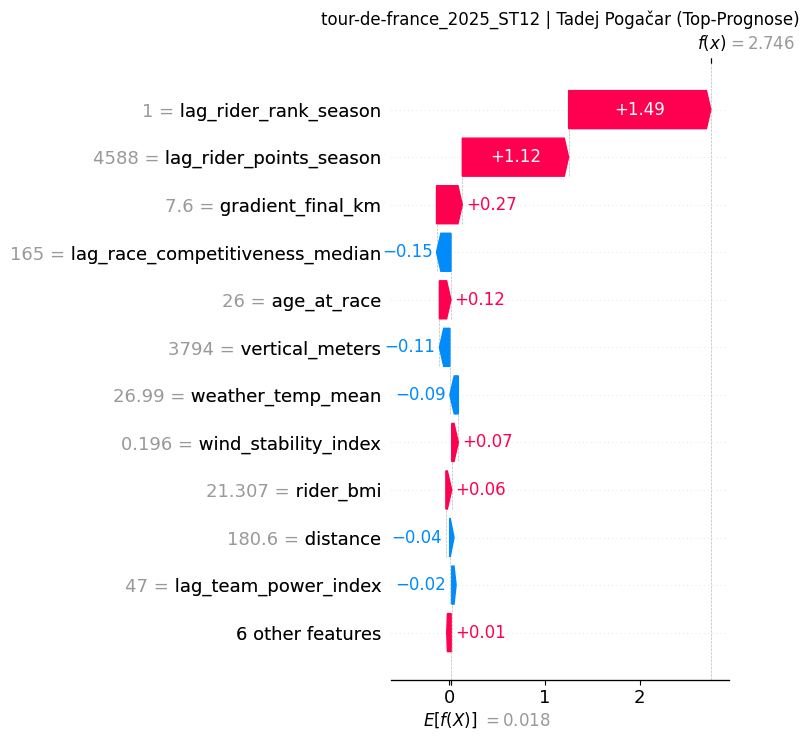


Schluss-Prognose: Alexey Lutsenko | Modell-Score: -3.1913 | Realer Rang: 71.


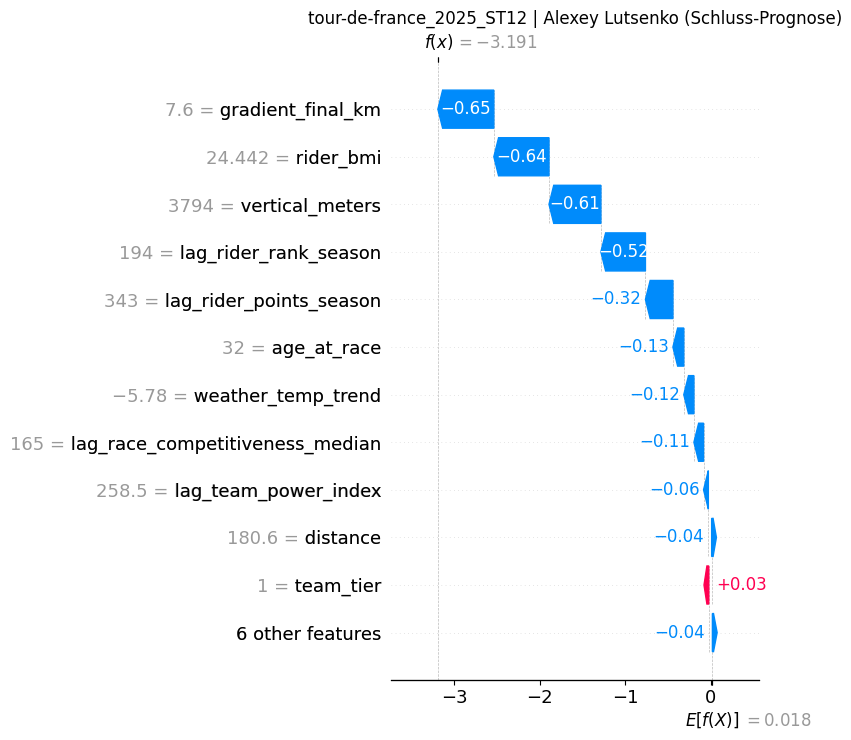

In [12]:
# Beispiel-Etappe für die lokale Analyse
example_stage = "tour-de-france_2025_ST12"

stage_mask = (meta_test["stage_id"] == example_stage).values
stage_positions = np.flatnonzero(stage_mask)
stage_scores = df_test_eval.loc[stage_mask, "score_tuned"].values
stage_names = meta_test.loc[stage_mask, "meta_name"].values

# Höchst- und niedrigstbewerteter Fahrer der Etappe (laut Modell)
pos_best = stage_positions[np.argmax(stage_scores)]
pos_worst = stage_positions[np.argmin(stage_scores)]

for pos, label in [(pos_best, "Top-Prognose"), (pos_worst, "Schluss-Prognose")]:
    rider_name = meta_test.iloc[pos]["meta_name"]
    real_rank = np.asarray(y_rank_test)[pos]
    real_rank_str = f"{int(real_rank)}." if not pd.isna(real_rank) else "DNF"
    print(f"\n{label}: {rider_name} | Modell-Score: {scores_check[pos]:.4f} | Realer Rang: {real_rank_str}")

    shap.plots.waterfall(shap_explanation[pos], max_display=12, show=False)
    plt.title(f"{example_stage} | {rider_name} ({label})")
    plt.tight_layout()
    plt.show()

# Qualitative Fallstudienanalyse: Tour de France 2025

Abschließend werden dieselben zwei Etappen wie im EBM-Notebook qualitativ untersucht (Etappe 12 und 16 der Tour de France 2025). Das erlaubt einen direkten Blick darauf, ob der native Ranker in genau den Situationen anders entscheidet, in denen das pointwise EBM an seine Grenzen stieß (Etappe 16: erfolgreiche Ausreißergruppe, die vom EBM tief eingestuft wurde).

In [13]:
# 1. Zentralen Analyse-Datenrahmen aufbauen
df_case_studies = pd.DataFrame(
    {
        "stage_id": meta_test["stage_id"].values,
        "Fahrer": meta_test["meta_name"].values,
        "Realer Rang": y_rank_test,
        "Score_Baseline": df_test_eval["score_baseline"].values,
        "Score_Tuned": df_test_eval["score_tuned"].values,
    }
)

# 2. Festlegung der beiden primären Testetappen der Tour de France 2025
#    (identisch zu Notebook 10-01 für den direkten Modellvergleich)
case_stages = ["tour-de-france_2025_ST12", "tour-de-france_2025_ST16"]

# 3. Iteration und strukturierter Output
for stage in case_stages:
    stage_data = df_case_studies[df_case_studies["stage_id"] == stage].copy()

    # 1-basierter Modell-Rang innerhalb dieser geschlossenen Etappe (getunter Ranker)
    stage_data["Pred_Rang_Tuned"] = (
        stage_data["Score_Tuned"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    print("\n" + "=" * 80)
    print(f"Analyse: {stage.upper()}")
    print("=" * 80)

    # A: Top-10-Prognose des getunten Rankers
    print("\n[TABELLE A] MODELL-PROGNOSE: Top 10 Fahrer sortiert nach Ranker-Score")
    print("-" * 80)
    top_10_preds = stage_data.sort_values("Score_Tuned", ascending=False).head(10)
    print(
        top_10_preds.to_string(
            index=False,
            columns=["Pred_Rang_Tuned", "Fahrer", "Score_Tuned", "Realer Rang"],
            formatters={
                "Score_Tuned": lambda x: f"{x:.4f}",
                "Realer Rang": lambda x: f"{int(x)}." if not pd.isna(x) else "DNF",
            },
        )
    )
    print("-" * 80)

    # B: Reale Top 10 und ihre Modellbewertung
    print("\n[TABELLE B] REALE ERGEBNISSE: Die tatsächliche Top 10 der Etappe und ihre Modell-Scores")
    print("-" * 80)
    true_top_10 = stage_data[stage_data["Realer Rang"] <= 10].sort_values(
        "Realer Rang", ascending=True
    )
    if not true_top_10.empty:
        print(
            true_top_10.to_string(
                index=False,
                columns=["Realer Rang", "Fahrer", "Score_Tuned", "Pred_Rang_Tuned"],
                formatters={
                    "Score_Tuned": lambda x: f"{x:.4f}",
                    "Realer Rang": lambda x: f"{int(x)}.",
                    "Pred_Rang_Tuned": lambda x: f"Platz {int(x)}",
                },
            )
        )
    else:
        print("Hinweis: Keine Fahrer mit realem Rang <= 10 im Test-Split dieser Etappe vorhanden.")
    print("-" * 80)
    print("=" * 80 + "\n")


Analyse: TOUR-DE-FRANCE_2025_ST12

[TABELLE A] MODELL-PROGNOSE: Top 10 Fahrer sortiert nach Ranker-Score
--------------------------------------------------------------------------------
 Pred_Rang_Tuned           Fahrer Score_Tuned Realer Rang
               1    Tadej Pogačar      2.7457          1.
               2     Marc Hirschi      2.4876         57.
               3        Enric Mas      2.0286         33.
               4     Ben O'Connor      1.7808         16.
               5 Matteo Jorgenson      1.7722         15.
               6 Aleksandr Vlasov      1.7396         34.
               7 Jonas Vingegaard      1.5283          2.
               8    Biniam Girmay      1.4049        117.
               9 Carlos Rodríguez      1.3130         22.
              10  Remco Evenepoel      1.3028          7.
--------------------------------------------------------------------------------

[TABELLE B] REALE ERGEBNISSE: Die tatsächliche Top 10 der Etappe und ihre Modell-Scores
-----

## Interpretation der Fallstudien

**Etappe 12 — der Ranker trifft den Sieger exakt.** Der getunte XGBRanker setzt **Tadej Pogačar auf Modellrang 1 — und Pogačar gewinnt die Etappe tatsächlich.** Das EBM hatte den Sieger nur auf Modellrang 11 geführt (und stattdessen Ben O'Connor auf Rang 1, real 16.). Auch Vingegaard (Modellrang 7 → real 2.) und Evenepoel (Modellrang 10 → real 7.) stehen in der prognostizierten Top 10. Der "Prominenz-Bias" des EBM bleibt allerdings auch beim Ranker klar erkennbar: Marc Hirschi (Modellrang 2 → real 57.), Enric Mas (3 → 33.) und Biniam Girmay (8 → 117.) werden auf Basis ihrer historischen Stärke deutlich überschätzt — die paarweise Konkurrenzbetrachtung ändert nichts daran, dass diese Fahrer *auf dem Papier* zur Spitzengruppe gehören.

**Etappe 16 — dieselbe strukturelle Grenze wie beim EBM.** Die von einer Ausreißergruppe entschiedene Etappe bleibt auch für den Ranker unprognostizierbar: Der reale Sieger Valentin Paret-Peintre landet auf Modellrang 48 (EBM: 37), Ben Healy auf 57 (EBM: 40), Ilan Van Wilder auf 59 (EBM: 49). Gleichzeitig sortiert der Ranker die "Sicherheits-Favoriten" korrekt nach vorn: Pogačar Modellrang 1 (real 5.), Mas 4 (real 7.), Vingegaard 7 (real 6.). Der direkte Vergleich mit den EBM-Fallstudien belegt damit die zentrale These aus der Einleitung: Der Prognosefehler bei Ausreißer-Etappen liegt an der **Informationslage** (keine tagesaktuelle Renndynamik in den historischen Features), nicht am **Modelltyp** — das native Ranking-Ziel kann Information nicht ersetzen, die in den Features nicht enthalten ist.

**Baseline vs. getunter Ranker:** Qualitativ zeigen beide Varianten dieselben Muster (Elite-Fahrer vorn, Ausreißer unsichtbar); die Unterschiede liegen in Nuancen der Reihenfolge innerhalb der Favoritengruppe. Bemerkenswert ist die deutlich gespreizte Score-Skala des getunten Modells (ca. −3 bis +3 gegenüber ca. −0.5 bis +0.4 der Baseline) — eine direkte Folge der tieferen Bäume und ein anschauliches Beispiel dafür, dass die absolute Höhe der Margin-Scores keine modellübergreifend vergleichbare Bedeutung trägt.

# Fazit und Ausblick

**1. Prognosequalität.** Das native Learning-to-Rank-Ziel liefert den erwarteten Vorteil — in moderatem Umfang. Der XGBRanker erreicht bei allen Kernmetriken der etappenweisen Sortierqualität (NDCG@5/10/20, MAP@10, Spearman Rho) das Niveau des getunten EBM-GA²M oder übertrifft es leicht; die Baseline-Variante zusätzlich bei den Winner-Hit-Rates @1/5/10 (Hit@1: 18.92 % vs. 16.22 %). Der qualitative Charakter der Prognosen bleibt jedoch derselbe wie bei den pointwise Modellen: starke Priorisierung der historischen Elite, keine Sicht auf tagesaktuelle Renndynamik. Das Trainingsziel verschiebt die Sortierqualität um wenige Prozentpunkte — es ersetzt keine fehlende Information.

**2. Interpretierbarkeit.** Die SHAP-Analysen gewinnen einen erheblichen Teil der Transparenz post-hoc zurück: Global dominieren die Fahrerform-Features `lag_rider_rank_season` und `lag_rider_points_season` zusammen mit `rider_bmi` und `vertical_meters` — konsistent mit dem EBM-Befund, dass isolierte Topografie- und Wettermerkmale wenig beitragen und die Prognosekraft primär aus Form- und Fahrereigenschaften stammt (bemerkenswert: `vertical_meters` schafft es beim Ranker in die Top 4, vermutlich über Interaktionen mit dem Fahrertyp, die die Dependence-Plots sichtbar machen). Der prinzipielle Unterschied bleibt: Das EBM *ist* seine Erklärung (exakte Shape-Functions per Konstruktion), SHAP liefert exakte Attributionen eines Black-Box-Modells auf der schwerer kommunizierbaren Margin-Score-Skala. Für Stakeholder-Kommunikation bleibt das EBM überlegen, für die Modellvalidierung ist SHAP vollwertig.

**3. Methodische Erkenntnisse.**
- **Auswahl-Overfitting ist bei diesem Datensatz real:** Der Grid-Search-Gewinner (Valid-NDCG@10 0.4524) unterliegt auf dem Testset der eigenen Baseline (0.4401 auf Valid) in fast allen etappenweisen Metriken. Eine einzelne Validierungssaison (57 Etappen) ist als Auswahlkriterium verrauscht. Empfehlung für Folgearbeiten: Modellauswahl über mehrere Saisons bzw. gruppiertes Zeitreihen-CV (z. B. rollierend über 2021–2023) statt einer einzigen Saison.
- **Gepoolte ROC-AUC vs. NDCG:** Die unkalibrierten Margin-Scores benachteiligen die gepoolte AUC empirisch nicht (Baseline exakt auf EBM-Niveau, 0.7757). Beide Metriken laufen grob parallel, tauschen aber im Grid mehrfach die Rangfolge — die Entscheidung, NDCG@10 als Auswahlkriterium zu verwenden, bleibt konzeptionell richtig.
- **LambdaMART-Paarbildung:** `mean` schlägt `topk` durchgehend (Bestätigung der Dokumentationsempfehlung für kleinere Datensätze); 4–8 Paare pro Fahrer sind besser als 2. Vorsicht bei Early Stopping mit flachen Bäumen: Alle `max_depth=3`-Läufe stoppten in Runde 0, weil die verrauschte interne `ndcg@10`-Metrik ihren Startwert nie übertraf — ein Fallstrick, der bei Ranking-Objectives offenbar schneller zuschlägt als bei glatten Klassifikations-Losses.

**4. Grenzen und mögliche Erweiterungen.**
- **Label-Ablation:** feingranulare Relevanz-Labels (z. B. `max(0, 21 - Rang)`, Stufen 0–20 — zulässig, da ≤ 31) statt der vierstufigen Kodierung; nutzt die volle Rangordnung der Top-20 und erzeugt mehr effective pairs, weicht aber von der projektweiten Relevanzdefinition ab.
- **Objective-Vergleich:** `rank:pairwise` (ungewichtete Paare) als Ablation, um den Beitrag der $\Delta$NDCG-Gewichtung zu isolieren.
- **Robustere Modellauswahl:** mehrjährige Validierung (s. o.) — die naheliegendste Verbesserung, da sie das beobachtete Auswahl-Overfitting direkt adressiert.
- **Strukturelle Grenze aller Modelle:** Tagesaktuelle Renndynamik (Ausreißergruppen, Taktik, Stürze) ist mit ausschließlich historischen Features nicht prognostizierbar — der Ranker ändert die *Zielfunktion*, nicht die *Informationslage*. Die Fallstudie zu Etappe 16 zeigt das im direkten Vergleich mit dem EBM eindrücklich.

**Endergebnis:** Der XGBRanker ist der bislang stärkste Kandidat des Projekts für die etappenweise Favoritensortierung und bestätigt die Hypothese aus dem EBM-Notebook, dass ein natives gruppenbasiertes Rankingziel die Sortierqualität verbessert. Der Vorsprung ist jedoch moderat und wird mit dem Verlust der Glass-Box-Transparenz bezahlt; SHAP schließt diese Lücke für Analysezwecke weitgehend, für die erklärende Kommunikation nur teilweise.